In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot  as plt
import os

batch_size = 16
chunk_size = 128

train_path = "./datasets/wikitext2/wiki.train.tokens"
test_path = "./datasets/wikitext2/wiki.test.tokens"
valid_path = "./datasets/wikitext2/wiki.valid.tokens"
vocab_path = "./datasets/wikitext2/vocab.json"

In [2]:
train_data = open(train_path, encoding="utf-8").read()
test_data = open(test_path, encoding="utf-8").read()
valid_data = open(valid_path, encoding="utf-8").read()
tokens_for_vocab = set()

def chunk_data(data_str, batch_size, chunk_size, vocab_set=None):

    data_str = data_str.lower()
    data_arr = data_str.split()
    data_batched = []
    data_batched_chunked=[] #chunk x batch x seq

    if vocab_set is not None: 
        vocab_set.update(data_arr)

    batches_num = len(data_arr)//batch_size
    entities_lost_in_batching = len(data_arr)%batch_size

    chunks_len = batches_num // chunk_size
    entities_lost_in_chunking = batches_num % chunk_size


    #A bit of an info block for shits and giggles
    print("Tokens lost by batching: ", entities_lost_in_batching)
    print("Tokens lost by chunking: ", entities_lost_in_chunking*batch_size)
    print("Total tokens loss: ", entities_lost_in_batching + entities_lost_in_chunking*batch_size)
    print("Source dataset size: ", len(data_arr))
    print("Target dataset size: ", len(data_arr) - (entities_lost_in_batching + entities_lost_in_chunking*batch_size))
    print("Relative token loss (%): ", (entities_lost_in_batching + entities_lost_in_chunking*batch_size)/(len(data_arr)/100))

    for i in trange(batch_size):
        batch = data_arr[i*batches_num:(i+1)*batches_num]
        data_batched.append(batch) #batch x long_seq

    for i in trange(chunks_len):
        chunked = []
        for j in range(len(data_batched)): #len(data_batched) is the batch size, preventing awkward out of bounds errors
            chunked.append(data_batched[j][i*chunk_size:(i+1)*chunk_size])
        data_batched_chunked.append(chunked) #chunk x batch x seq

    return data_batched_chunked
    
    
if os.path.exists(vocab_path):
    tokens_for_vocab = None

print("Chunking test data.")
test_data_chunked = chunk_data(test_data, batch_size=batch_size, chunk_size=chunk_size, vocab_set=tokens_for_vocab)
print("Chunking training data.")
train_data_chunked = chunk_data(train_data, batch_size=batch_size, chunk_size=chunk_size, vocab_set=tokens_for_vocab)
print("Chunking validation data.")
validation_data_chunked = chunk_data(valid_data, batch_size=batch_size, chunk_size=chunk_size, vocab_set=tokens_for_vocab)



Chunking test data.
Tokens lost by batching:  11
Tokens lost by chunking:  1584
Total tokens loss:  1595
Source dataset size:  241211
Target dataset size:  239616
Relative token loss (%):  0.6612467922275518


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

Chunking training data.
Tokens lost by batching:  6
Tokens lost by chunking:  1856
Total tokens loss:  1862
Source dataset size:  2051910
Target dataset size:  2050048
Relative token loss (%):  0.09074472077235357


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

Chunking validation data.
Tokens lost by batching:  14
Tokens lost by chunking:  880
Total tokens loss:  894
Source dataset size:  213886
Target dataset size:  212992
Relative token loss (%):  0.41797967141374376


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

In [3]:
if tokens_for_vocab != None:
    len(tokens_for_vocab)

In [4]:
print(train_data_chunked[0][0]) #First chunk of first batch 

['=', 'valkyria', 'chronicles', 'iii', '=', 'senjō', 'no', 'valkyria', '3', ':', '<unk>', 'chronicles', '(', 'japanese', ':', '戦場のヴァルキュリア3', ',', 'lit', '.', 'valkyria', 'of', 'the', 'battlefield', '3', ')', ',', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', ',', 'is', 'a', 'tactical', 'role', '@-@', 'playing', 'video', 'game', 'developed', 'by', 'sega', 'and', 'media.vision', 'for', 'the', 'playstation', 'portable', '.', 'released', 'in', 'january', '2011', 'in', 'japan', ',', 'it', 'is', 'the', 'third', 'game', 'in', 'the', 'valkyria', 'series', '.', '<unk>', 'the', 'same', 'fusion', 'of', 'tactical', 'and', 'real', '@-@', 'time', 'gameplay', 'as', 'its', 'predecessors', ',', 'the', 'story', 'runs', 'parallel', 'to', 'the', 'first', 'game', 'and', 'follows', 'the', '"', 'nameless', '"', ',', 'a', 'penal', 'military', 'unit', 'serving', 'the', 'nation', 'of', 'gallia', 'during', 'the', 'second', 'europan', 'war', 'who', 'perform', 'secret', '

In [5]:
import json

vocab_dict = dict()
if not os.path.exists(vocab_path):
    tokens_for_vocab = list(tokens_for_vocab)
    for i in trange(len(tokens_for_vocab)):
        vocab_dict[tokens_for_vocab[i]] = len(vocab_dict)
    print("New vocab created.")
else:
    with open(vocab_path, encoding="utf-8") as fp:
        vocab_dict = json.load(fp)
    print(f"Existing vocab loaded from {vocab_path}")
    print(f"Manual verification by token 0 id: {vocab_dict['0']}")

Existing vocab loaded from ./datasets/wikitext2/vocab.json
Manual verification by token 0 id: 10600


In [6]:
def map_tokens_to_vocab(batched_chunked_data, vocab):
    for chunk in tqdm(batched_chunked_data):
        for batch_seq in chunk:
            for i in range(len(batch_seq)):
                batch_seq[i] = vocab[batch_seq[i]]

In [7]:
map_tokens_to_vocab(test_data_chunked, vocab_dict)
map_tokens_to_vocab(train_data_chunked, vocab_dict)
map_tokens_to_vocab(validation_data_chunked, vocab_dict)

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

In [8]:
print(train_data_chunked[0][0]) #First chunk of first batch 

[16916, 12450, 7984, 8155, 16916, 11042, 624, 12450, 18449, 23170, 13971, 7984, 28085, 7431, 23170, 28211, 27989, 24362, 6911, 12450, 7196, 13372, 12489, 18449, 13457, 27989, 13473, 25293, 25667, 1063, 12450, 7984, 8155, 28569, 13642, 27989, 18503, 10188, 28080, 18972, 13461, 15233, 21033, 13068, 7386, 5320, 9800, 19593, 13997, 14930, 13372, 12224, 19379, 6911, 8383, 27290, 19235, 9964, 27290, 13642, 27989, 24009, 18503, 13372, 13081, 13068, 27290, 13372, 12450, 15479, 6911, 13971, 13372, 8144, 2462, 7196, 28080, 19593, 21817, 13461, 1303, 14122, 1063, 1888, 15905, 27989, 13372, 24359, 2532, 17427, 25667, 13372, 22936, 13068, 19593, 13521, 13372, 24749, 6727, 24749, 27989, 10188, 22563, 22222, 28786, 8706, 13372, 12774, 7196, 21651, 6215, 13372, 14837, 6541, 25704, 24433, 20079, 9532, 23795, 24893, 19593, 25325, 19413, 31, 13372, 6493, 28786, 24749]


In [9]:
def evaluate_model(model, encoded_data, hid, device):
    cell_state = model.init_hid.unsqueeze(0).expand(batch_size, -1)
    m = torch.zeros((batch_size, hid), device=device)
    norm = torch.ones((batch_size, hid), device=device)

    model.eval()
    with torch.no_grad():

        loss_sum = 0

        for i in trange(len(encoded_data)):
            is_last_chunk = (i == (len(encoded_data)-1))
            chunk = encoded_data[i]

            inputs = torch.tensor(chunk, device=device)
            if not is_last_chunk:
                pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
                next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
                outputs = next_token[:, 1:]
            else:
                outputs = inputs[:, 1:]

            logits, cell_state, m, norm = model.forward(cell_state, m, norm, inputs)
            if is_last_chunk:
                logits = logits[:, :-1]
            loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)

            loss_sum = loss_sum + loss_t.item()


        loss_avg = loss_sum/len(encoded_data)
        ppl_avg = math.exp(loss_avg)
        
    model.train()

    return loss_avg, ppl_avg

In [10]:
def evaluate_model_hid_state(model, hid_state, encoded_data, hid, device):
    loc_hid_state = model.init_hid.unsqueeze(0).expand(batch_size, -1)
    model.eval()
    with torch.no_grad():

        loss_sum = 0

        for i in trange(len(encoded_data)):
            is_last_chunk = (i == (len(encoded_data)-1))
            chunk = encoded_data[i]

            inputs = torch.tensor(chunk, device=device)
            if not is_last_chunk:
                pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
                next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
                outputs = next_token[:, 1:]
            else:
                outputs = inputs[:, 1:]

            logits, loc_hid_state = model.forward(loc_hid_state, inputs)
            if is_last_chunk:
                logits = logits[:, :-1]
            loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)

            loss_sum = loss_sum + loss_t.item()


        loss_avg = loss_sum/len(encoded_data)
        ppl_avg = math.exp(loss_avg)
        
    model.train()

    return loss_avg, ppl_avg

In [11]:
def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} WikiText-2-word Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)


def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [13]:
def train_model(model, model_name, cell_state, opt, encoded_data, encoded_eval_data, train_loss_history, test_loss_history, ppl_history, start_step, recorded_steps, break_time, hid, device):
    
    m = torch.zeros((batch_size, hid), device=device)
    norm = torch.ones((batch_size, hid), device=device)

    step = start_step

    for i in trange(len(encoded_data)):
        is_last_chunk = (i == (len(encoded_data)-1))
        chunk = encoded_data[i]

        inputs = torch.tensor(chunk, device=device)
        if not is_last_chunk:
            pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
            next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
            outputs = next_token[:, 1:]
        else:
            outputs = inputs[:, 1:]

        opt.zero_grad()
    
        logits, cell_state, m, norm = model.forward(cell_state, m, norm, inputs)
        if is_last_chunk:
            logits = logits[:, :-1]
        loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)
    
        loss_t.backward()
    
        opt.step()

        cell_state = cell_state.detach()
        m = m.detach()
        norm = norm.detach()

        if step % 1000 ==0 and step !=0:
            save_model(model, opt, step, model_name, note="wikitext2")

        if step % break_time ==0:
            eval_loss, eval_ppl = evaluate_model(model, encoded_eval_data, hid, device)

            train_loss_history.append(loss_t.item())
            test_loss_history.append(eval_loss)
            ppl_history.append(eval_ppl)
            recorded_steps.append(step)

            plot_loss_curves(recorded_steps, train_loss_history, test_loss_history, model_name=model_name)

            print(f"Step: {step}")
            print(f"Training loss: {loss_t.item()}")
            print(f"Validation loss: {eval_loss}")
            print(f"PPL measurement: {eval_ppl}")

        step = step + 1

    return step
        

In [14]:
def train_model_hid_state(model, model_name, hid_state, opt, encoded_data, encoded_eval_data, train_loss_history, test_loss_history, ppl_history, start_step, recorded_steps, break_time, hid, device):

    step = start_step
    loc_hid_state = hid_state

    for i in trange(len(encoded_data)):
        is_last_chunk = (i == (len(encoded_data)-1))
        chunk = encoded_data[i]

        inputs = torch.tensor(chunk, device=device)
        if not is_last_chunk:
            pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
            next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
            outputs = next_token[:, 1:]
        else:
            outputs = inputs[:, 1:]

        opt.zero_grad()
    
        logits, loc_hid_state  = model.forward(loc_hid_state, inputs)
        if is_last_chunk:
            logits = logits[:, :-1]
        loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)
    
        loss_t.backward()
    
        opt.step()

        loc_hid_state = loc_hid_state.detach()


        if step % 1000 ==0 and step !=0:
            save_model(model, opt, step, model_name, note="wikitext2")

        if step % break_time ==0:
            eval_loss, eval_ppl = evaluate_model_hid_state(model, hid_state, encoded_eval_data, hid, device)

            train_loss_history.append(loss_t.item())
            test_loss_history.append(eval_loss)
            ppl_history.append(eval_ppl)
            recorded_steps.append(step)

            plot_loss_curves(recorded_steps, train_loss_history, test_loss_history, model_name=model_name)

            print(f"Step: {step}")
            print(f"Training loss: {loss_t.item()}")
            print(f"Validation loss: {eval_loss}")
            print(f"PPL measurement: {eval_ppl}")

        step = step + 1

    return step
        

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

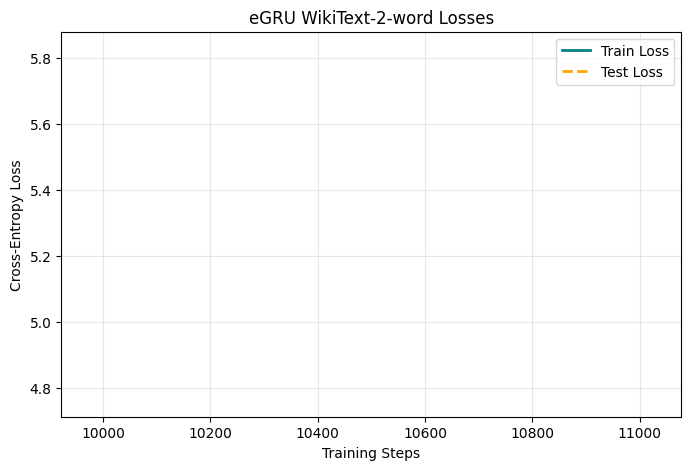

Step: 10500
Training loss: 4.766215801239014
Validation loss: 5.826664599088522
PPL measurement: 339.225337548211


  0%|          | 0/104 [00:00<?, ?it/s]

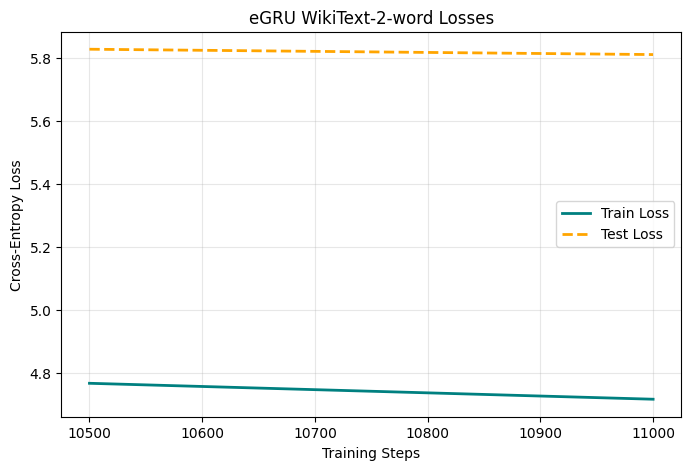

Step: 11000
Training loss: 4.715631008148193
Validation loss: 5.809703620580526
PPL measurement: 333.52026248300643


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

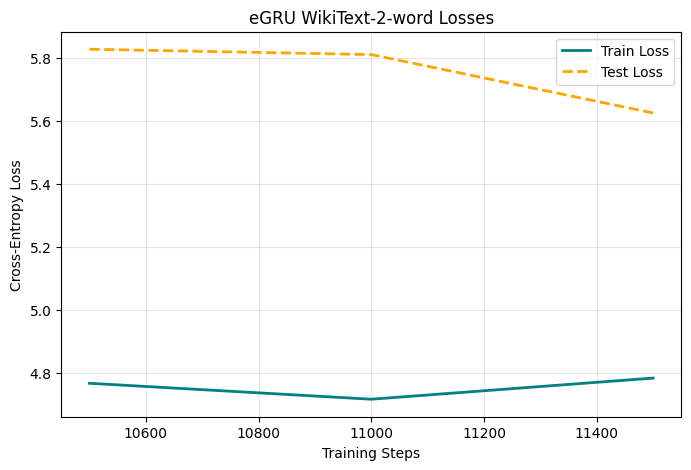

Step: 11500
Training loss: 4.782773017883301
Validation loss: 5.624247596814082
PPL measurement: 277.06374243659536


  0%|          | 0/104 [00:00<?, ?it/s]

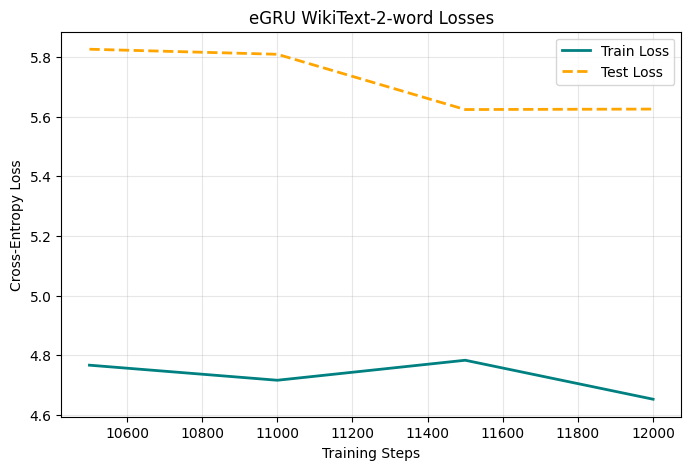

Step: 12000
Training loss: 4.651952743530273
Validation loss: 5.6257836268498345
PPL measurement: 277.489647684683


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

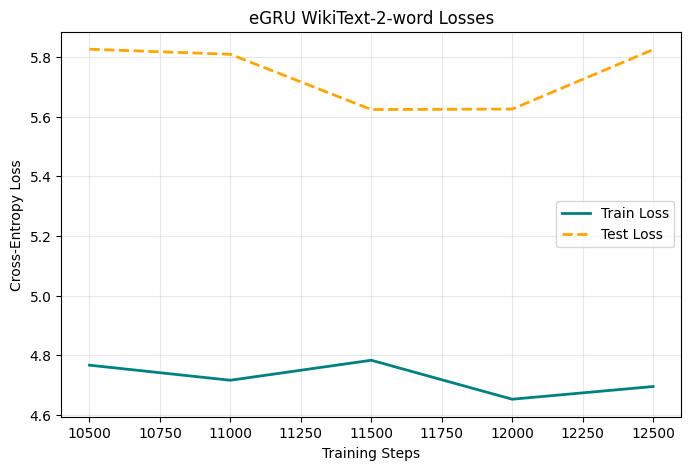

Step: 12500
Training loss: 4.694597244262695
Validation loss: 5.825227411893698
PPL measurement: 338.73815740531444


  0%|          | 0/104 [00:00<?, ?it/s]

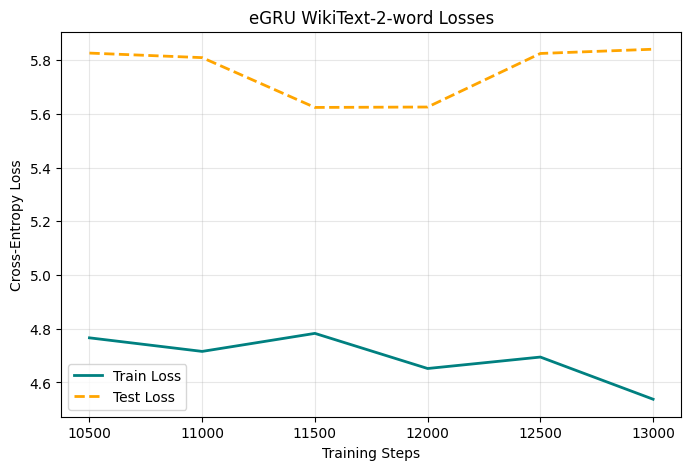

Step: 13000
Training loss: 4.5375657081604
Validation loss: 5.841040349923647
PPL measurement: 344.13717758130826


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

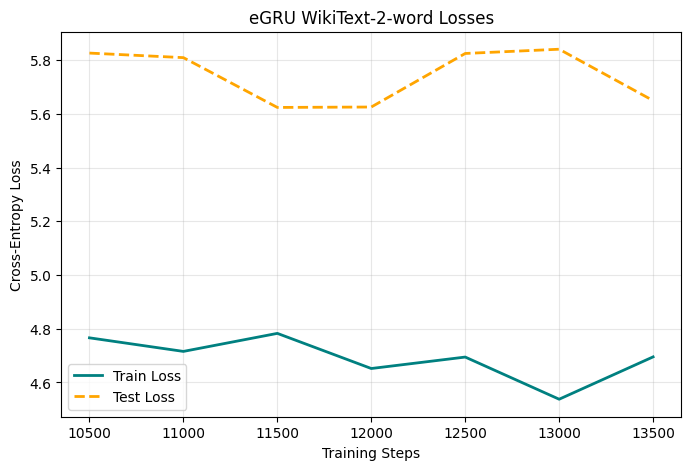

Step: 13500
Training loss: 4.69525146484375
Validation loss: 5.64977089716838
PPL measurement: 284.22634130448586


  0%|          | 0/104 [00:00<?, ?it/s]

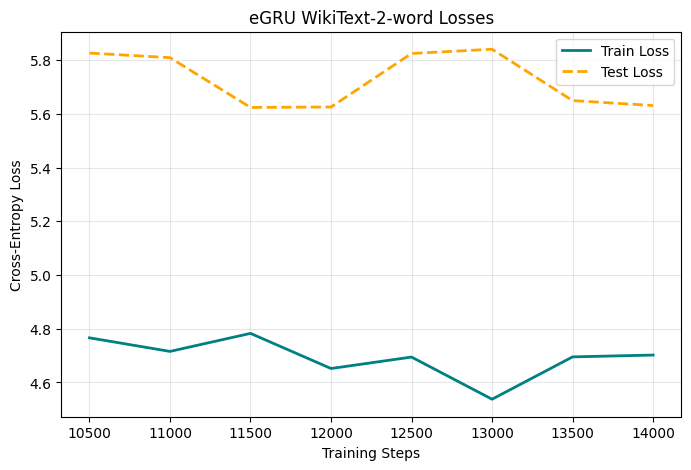

Step: 14000
Training loss: 4.702068328857422
Validation loss: 5.631443867316613
PPL measurement: 279.06475936773836


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

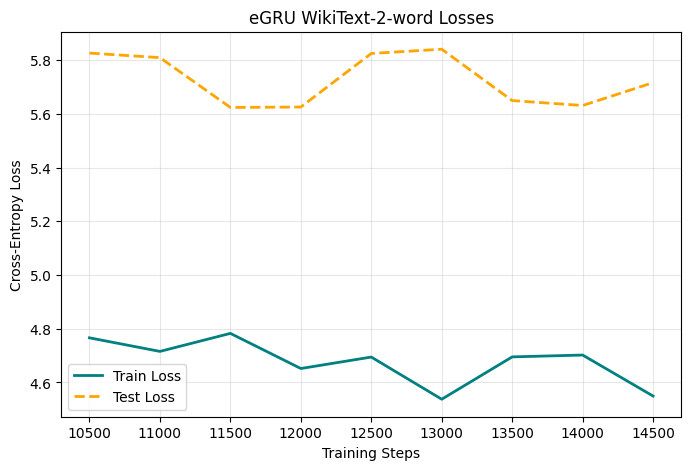

Step: 14500
Training loss: 4.549373626708984
Validation loss: 5.716482850221487
PPL measurement: 303.83441035479433


  0%|          | 0/104 [00:00<?, ?it/s]

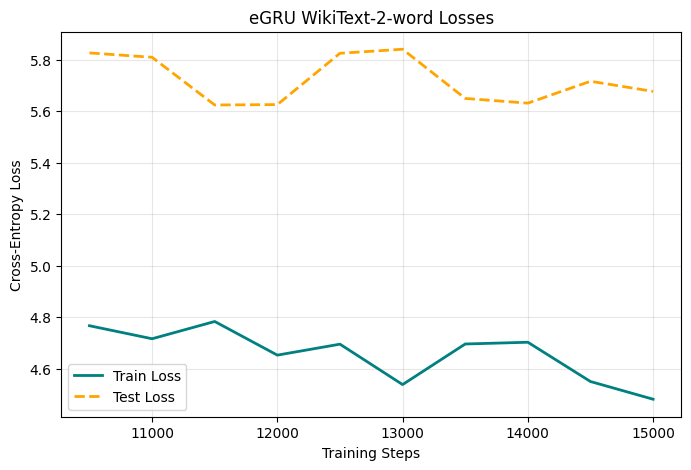

Step: 15000
Training loss: 4.480597019195557
Validation loss: 5.677109640378219
PPL measurement: 292.1039232169255


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

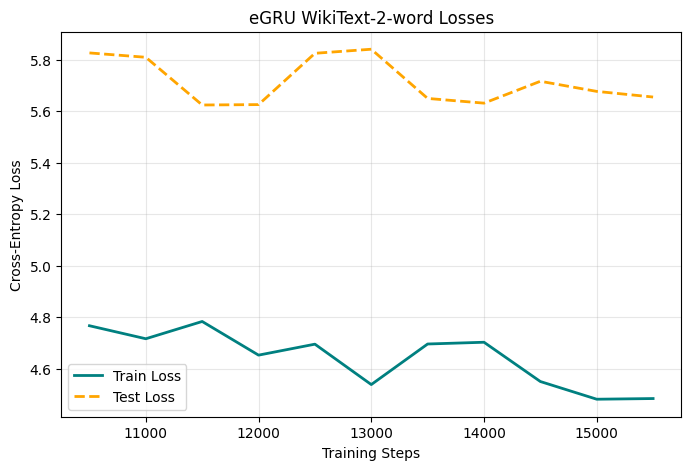

Step: 15500
Training loss: 4.483215808868408
Validation loss: 5.655212461948395
PPL measurement: 285.77719305621065


  0%|          | 0/104 [00:00<?, ?it/s]

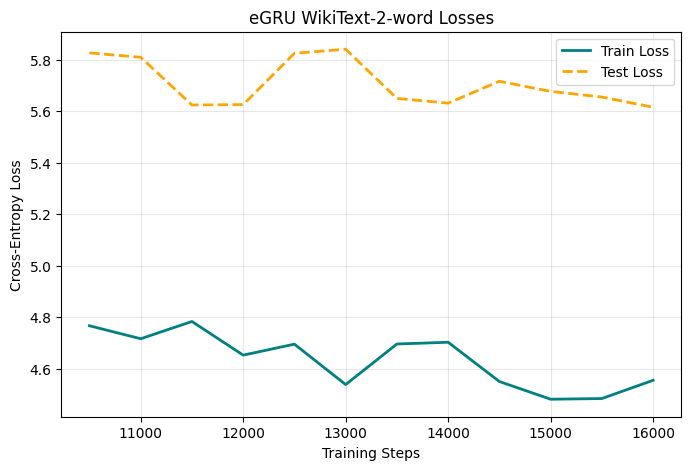

Step: 16000
Training loss: 4.554131984710693
Validation loss: 5.615489996396578
PPL measurement: 274.6479227222287


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

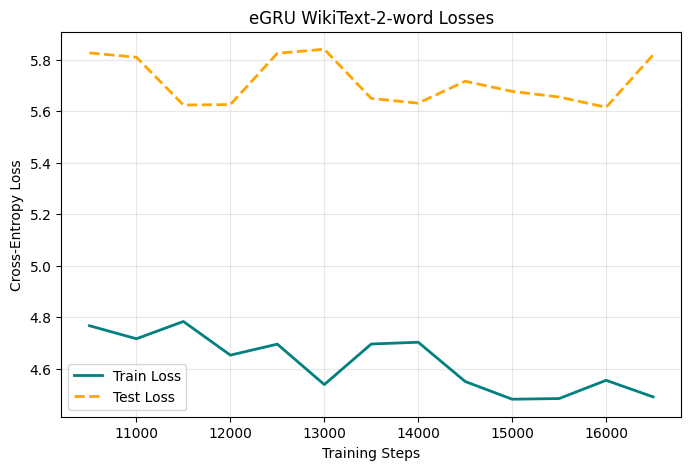

Step: 16500
Training loss: 4.489669322967529
Validation loss: 5.819170227417579
PPL measurement: 336.6925594332741


  0%|          | 0/104 [00:00<?, ?it/s]

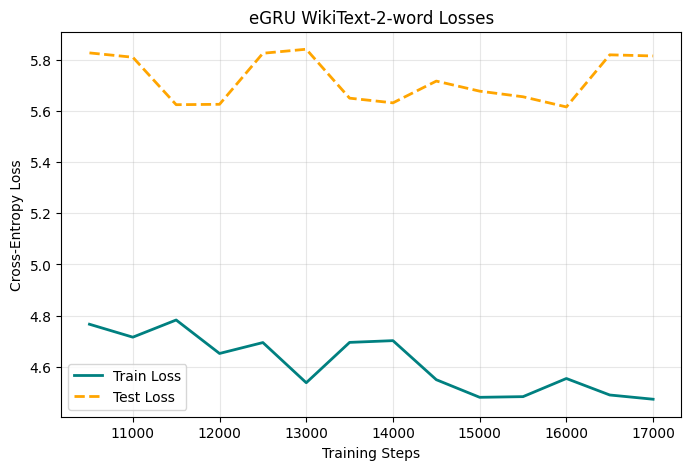

Step: 17000
Training loss: 4.473137378692627
Validation loss: 5.814691543579102
PPL measurement: 335.1879916654381


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

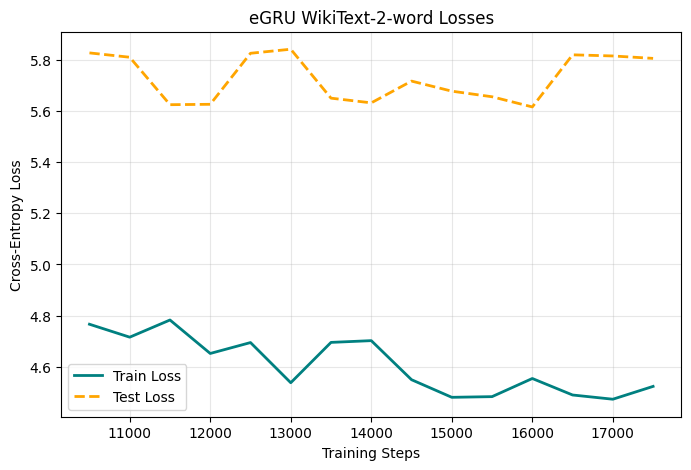

Step: 17500
Training loss: 4.523314476013184
Validation loss: 5.805246742872091
PPL measurement: 332.03711102724463


  0%|          | 0/104 [00:00<?, ?it/s]

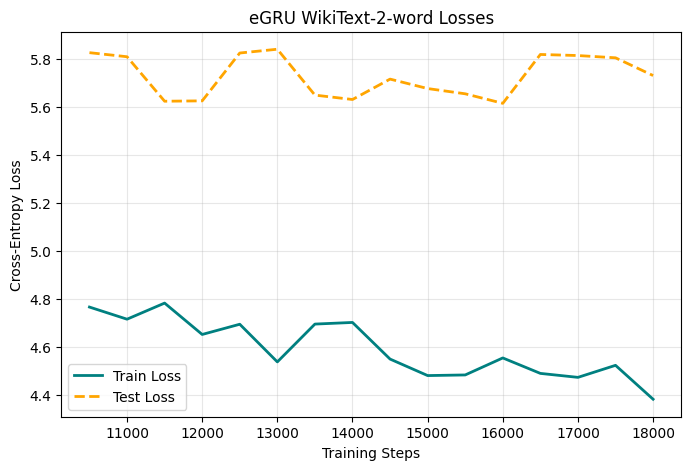

Step: 18000
Training loss: 4.382021427154541
Validation loss: 5.731309212171114
PPL measurement: 308.37272954240467


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

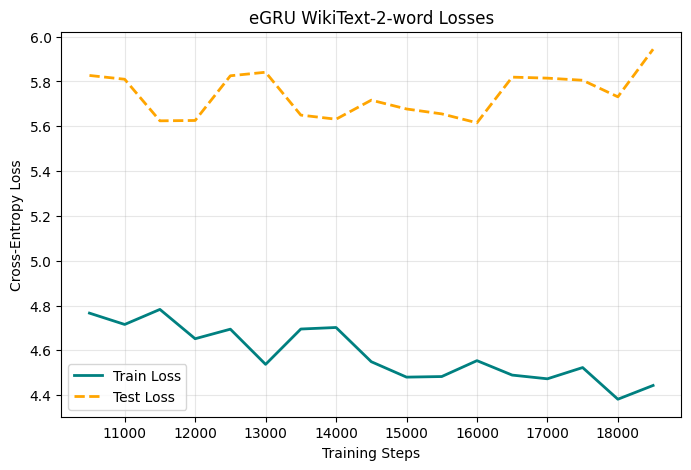

Step: 18500
Training loss: 4.443492889404297
Validation loss: 5.943721541991601
PPL measurement: 381.3515076249592


  0%|          | 0/104 [00:00<?, ?it/s]

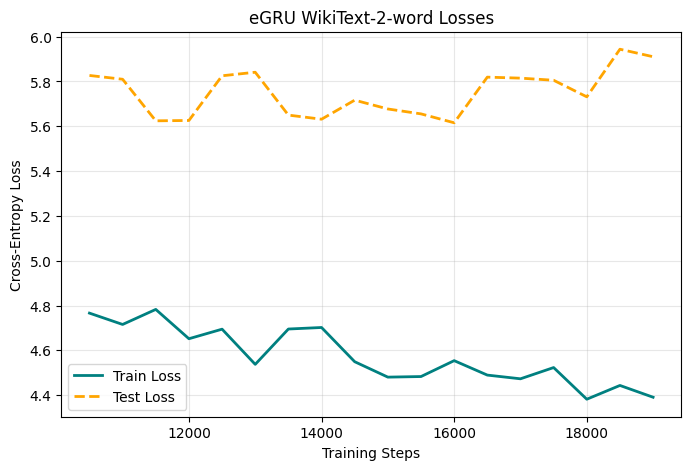

Step: 19000
Training loss: 4.390896320343018
Validation loss: 5.91020502952429
PPL measurement: 368.78175880720283


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

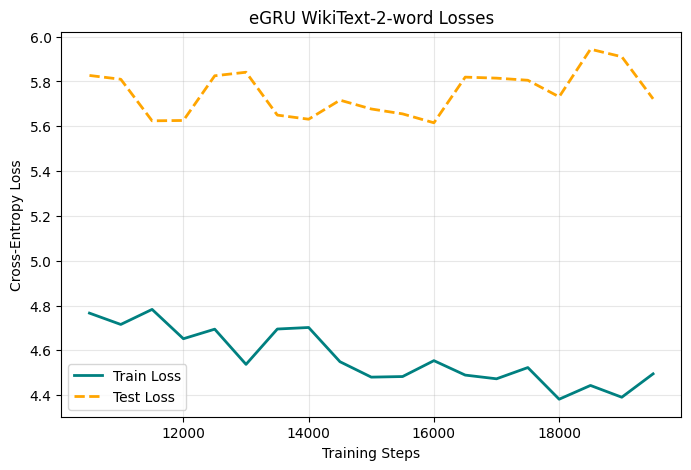

Step: 19500
Training loss: 4.495325088500977
Validation loss: 5.722308369783255
PPL measurement: 305.60956924703345


  0%|          | 0/104 [00:00<?, ?it/s]

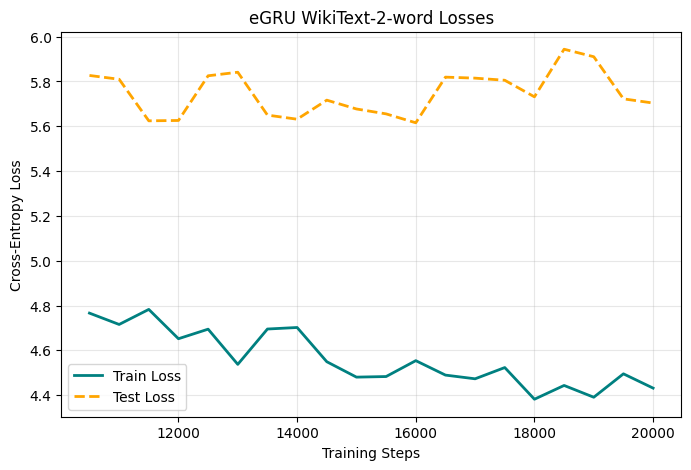

Step: 20000
Training loss: 4.431615829467773
Validation loss: 5.703570177921882
PPL measurement: 299.93631773971134


In [30]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =10001

steps_history = []
train_history = []
test_history = []
ppl_history=[]




eGRU_model = custom_models_for_lm.eGRU(vocab, hid, emb, device='cuda')
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)
_ = load_model("eGRU_wikitext2_epoch_10000.pt", device='cuda', model=eGRU_model, optimizer=opt_eGRU)

cell_state = eGRU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(10, 20):

    start_step = train_model(
        model=eGRU_model,
        model_name="eGRU",
        cell_state=cell_state,
        opt=opt_eGRU,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

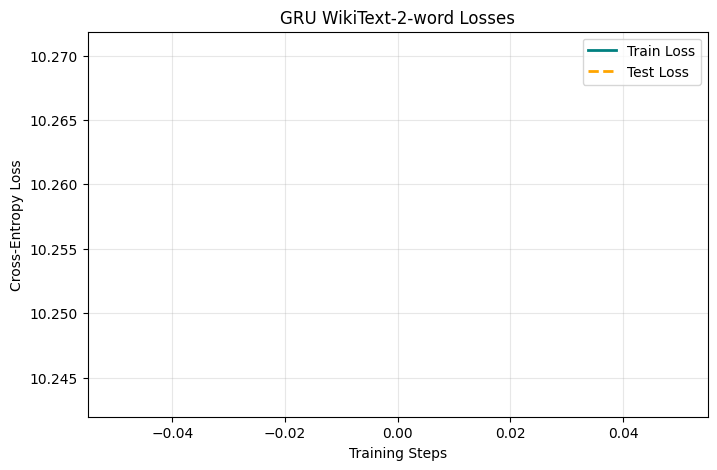

Step: 0
Training loss: 10.270491600036621
Validation loss: 10.24332317022177
PPL measurement: 28094.33322015983


  0%|          | 0/104 [00:00<?, ?it/s]

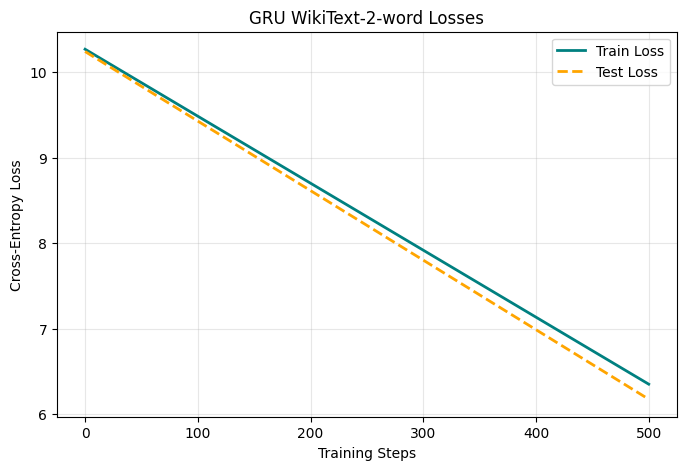

Step: 500
Training loss: 6.35167121887207
Validation loss: 6.175625241719759
PPL measurement: 480.8835984331428


  0%|          | 0/104 [00:00<?, ?it/s]

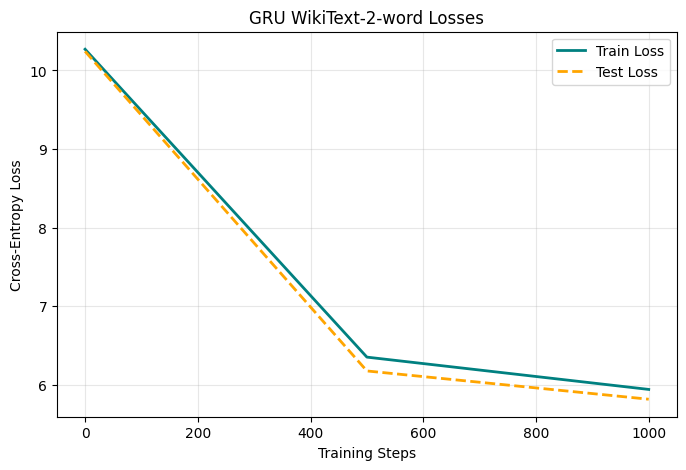

Step: 1000
Training loss: 5.940583229064941
Validation loss: 5.815852444905501
PPL measurement: 335.5773378020525


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

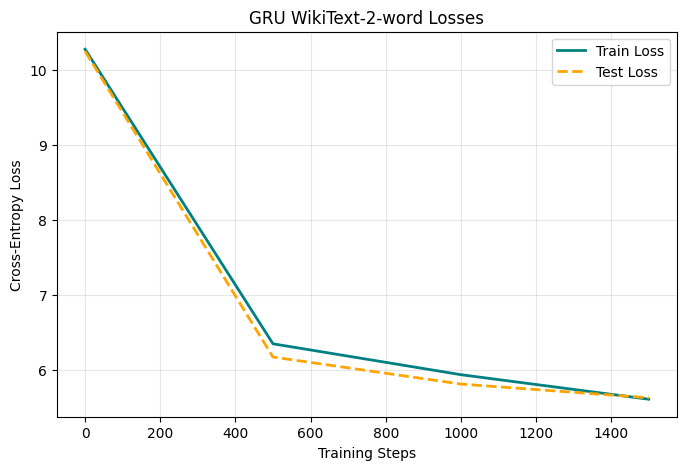

Step: 1500
Training loss: 5.614193916320801
Validation loss: 5.633293697467217
PPL measurement: 279.5814595300173


  0%|          | 0/104 [00:00<?, ?it/s]

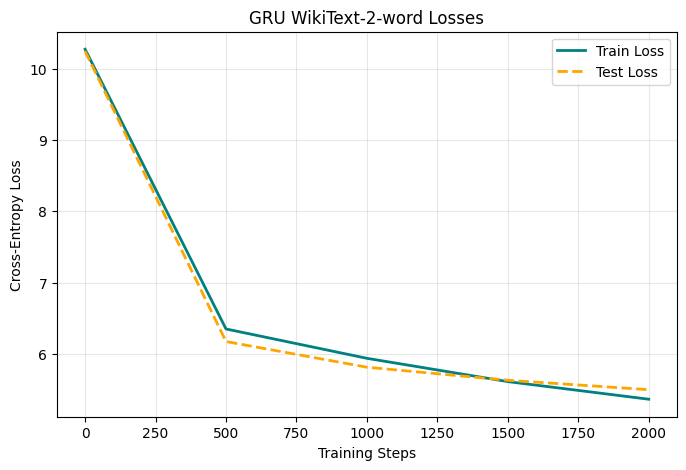

Step: 2000
Training loss: 5.367500305175781
Validation loss: 5.500792957269228
PPL measurement: 244.88603945981572


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

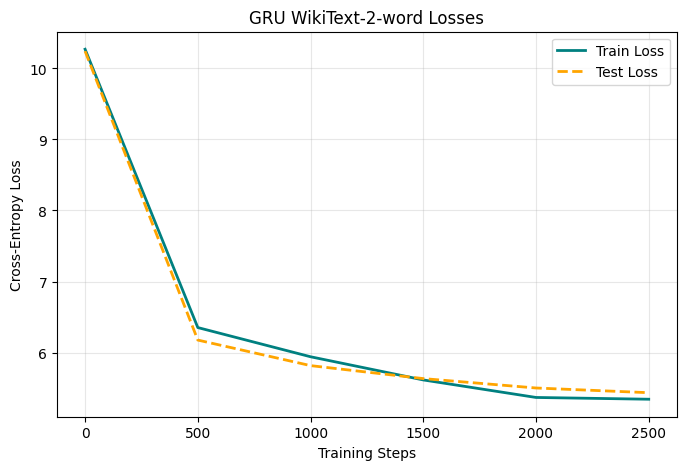

Step: 2500
Training loss: 5.3426995277404785
Validation loss: 5.434565177330604
PPL measurement: 229.19316822053204


  0%|          | 0/104 [00:00<?, ?it/s]

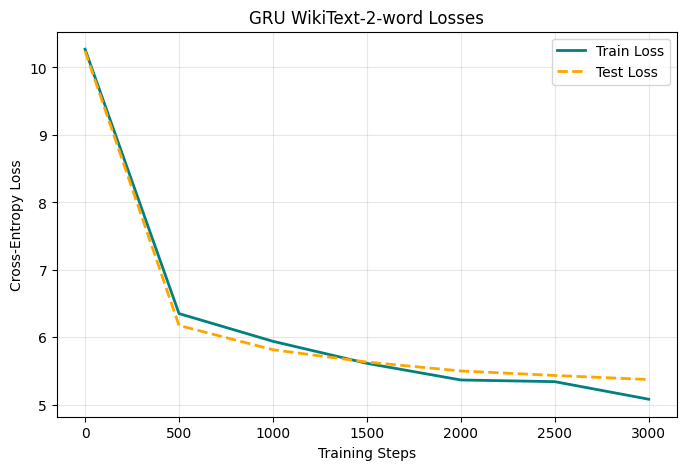

Step: 3000
Training loss: 5.082242012023926
Validation loss: 5.374148552234356
PPL measurement: 215.756089040852


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

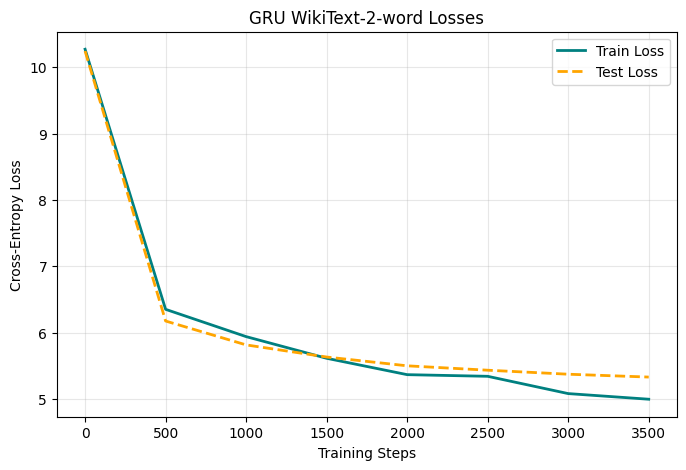

Step: 3500
Training loss: 4.997417449951172
Validation loss: 5.33117891733463
PPL measurement: 206.68149097746362


  0%|          | 0/104 [00:00<?, ?it/s]

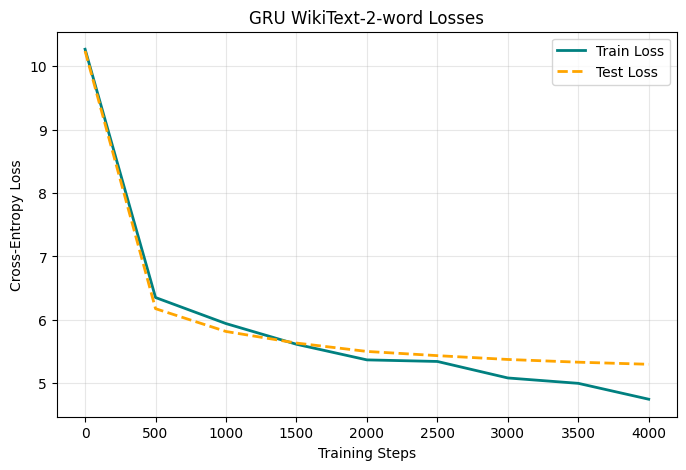

Step: 4000
Training loss: 4.746684551239014
Validation loss: 5.298081847337576
PPL measurement: 199.95290170440225


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

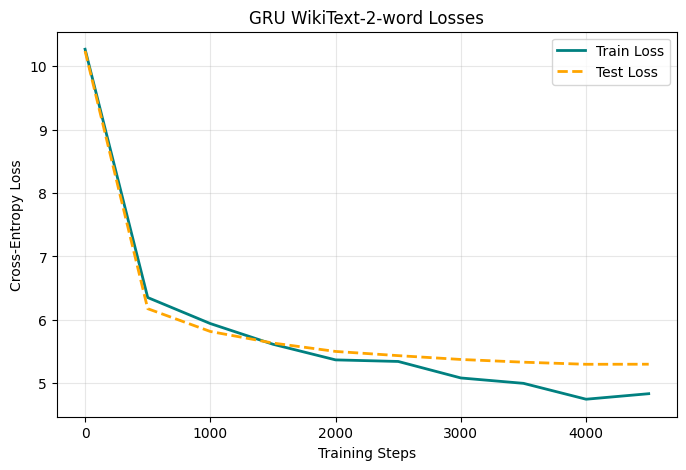

Step: 4500
Training loss: 4.833820343017578
Validation loss: 5.299189980213459
PPL measurement: 200.17459890069873


  0%|          | 0/104 [00:00<?, ?it/s]

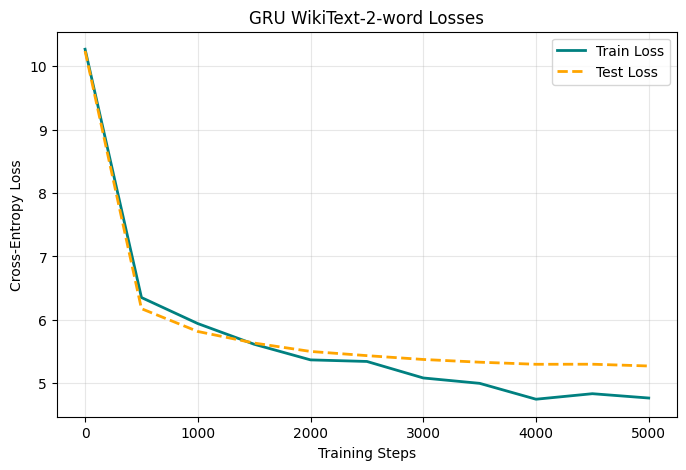

Step: 5000
Training loss: 4.765614986419678
Validation loss: 5.271149346461663
PPL measurement: 194.6395422046105


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

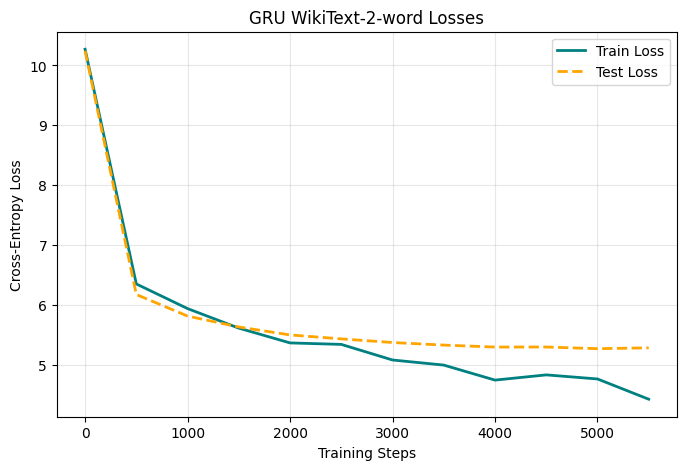

Step: 5500
Training loss: 4.427448749542236
Validation loss: 5.285197597283584
PPL measurement: 197.39318395178034


  0%|          | 0/104 [00:00<?, ?it/s]

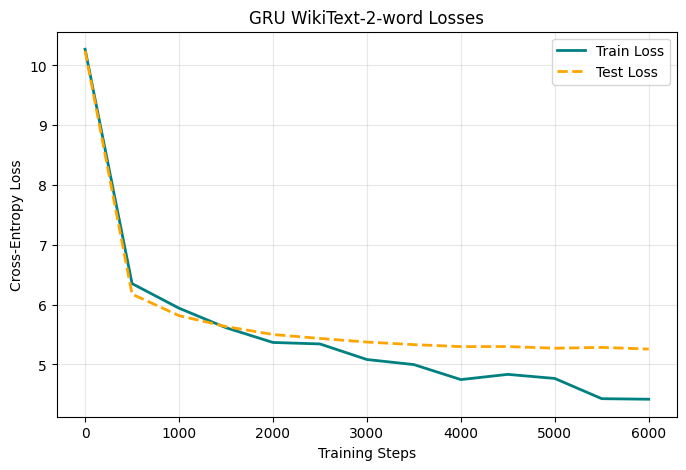

Step: 6000
Training loss: 4.418404579162598
Validation loss: 5.257252184244303
PPL measurement: 191.95331362258048


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

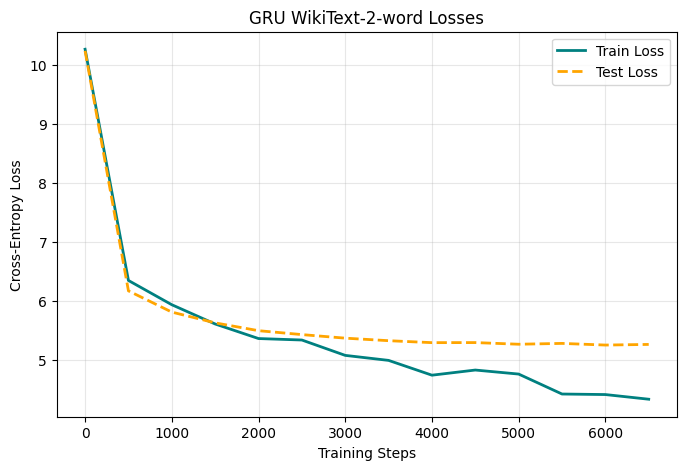

Step: 6500
Training loss: 4.339338302612305
Validation loss: 5.267919246967022
PPL measurement: 194.01185141530198


  0%|          | 0/104 [00:00<?, ?it/s]

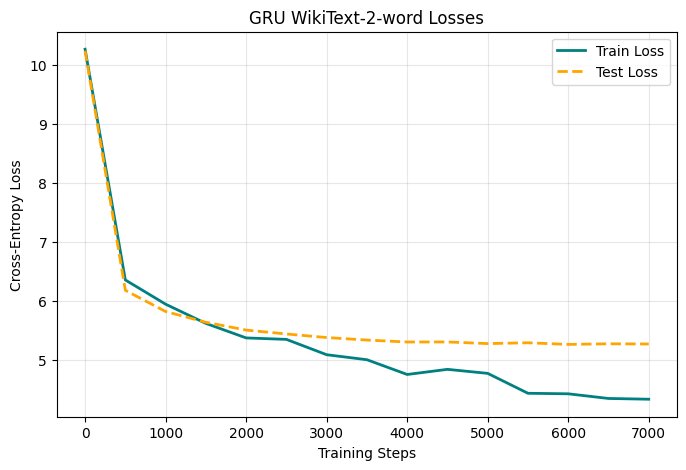

Step: 7000
Training loss: 4.326444149017334
Validation loss: 5.2646091763789835
PPL measurement: 193.3707201724194


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

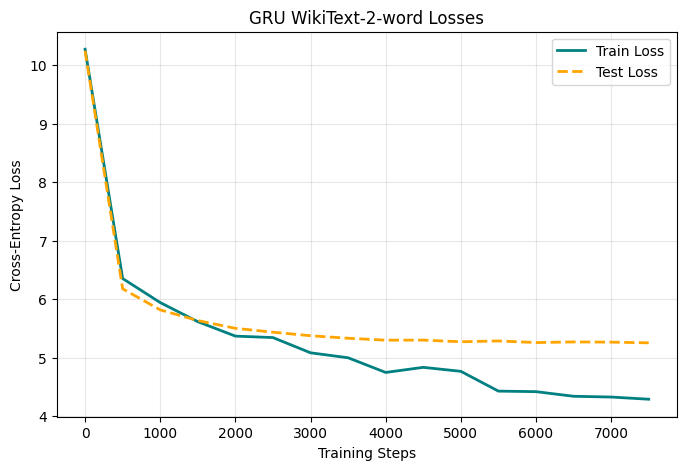

Step: 7500
Training loss: 4.289027214050293
Validation loss: 5.252505774681385
PPL measurement: 191.0443833632011


  0%|          | 0/104 [00:00<?, ?it/s]

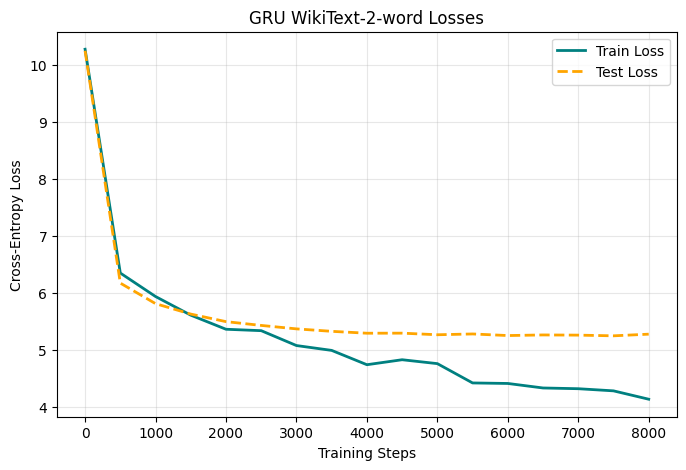

Step: 8000
Training loss: 4.142470359802246
Validation loss: 5.281503865352044
PPL measurement: 196.66541137101598


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

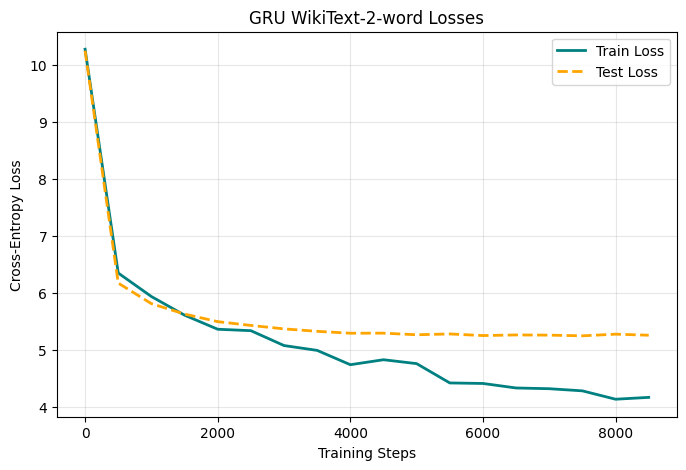

Step: 8500
Training loss: 4.174741744995117
Validation loss: 5.262960585264059
PPL measurement: 193.0521935534759


  0%|          | 0/104 [00:00<?, ?it/s]

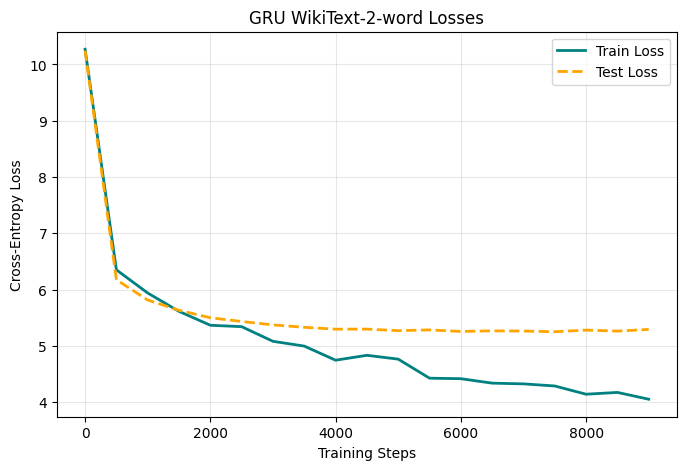

Step: 9000
Training loss: 4.053765773773193
Validation loss: 5.293724303062145
PPL measurement: 199.08349369986783


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

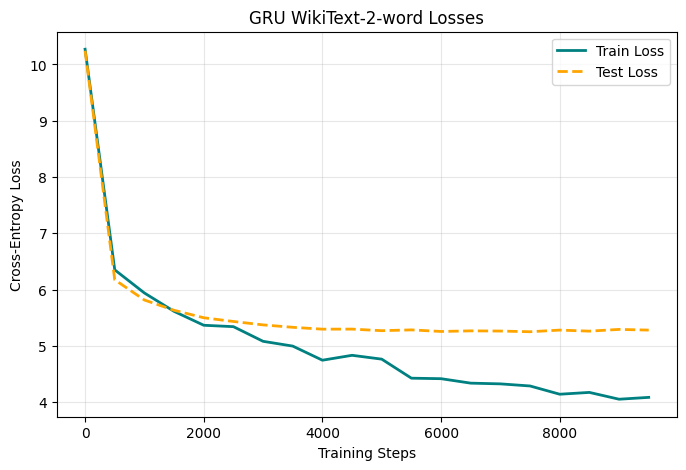

Step: 9500
Training loss: 4.086666584014893
Validation loss: 5.281548467966227
PPL measurement: 196.6741833581077


  0%|          | 0/104 [00:00<?, ?it/s]

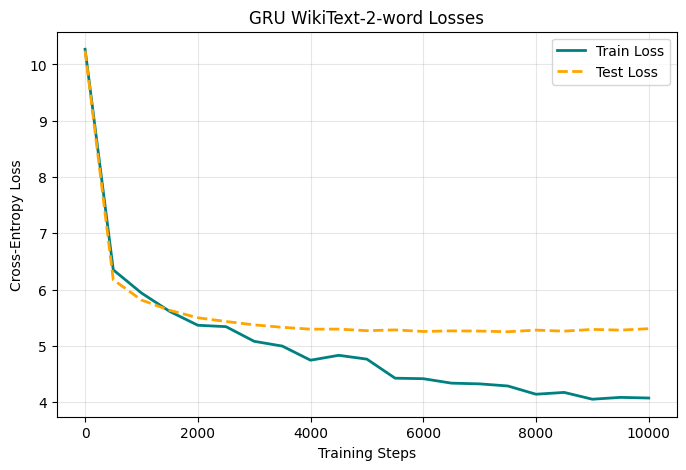

Step: 10000
Training loss: 4.075062274932861
Validation loss: 5.306847242208628
PPL measurement: 201.71327174163196


In [15]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




GRU_model = custom_models_for_lm.GRU_LM(vocab, hid, emb, device='cuda')
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)
hid_state = GRU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(epochs):

    start_step = train_model_hid_state(
        model=GRU_model,
        model_name="GRU",
        hid_state=hid_state,
        opt=opt_GRU,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

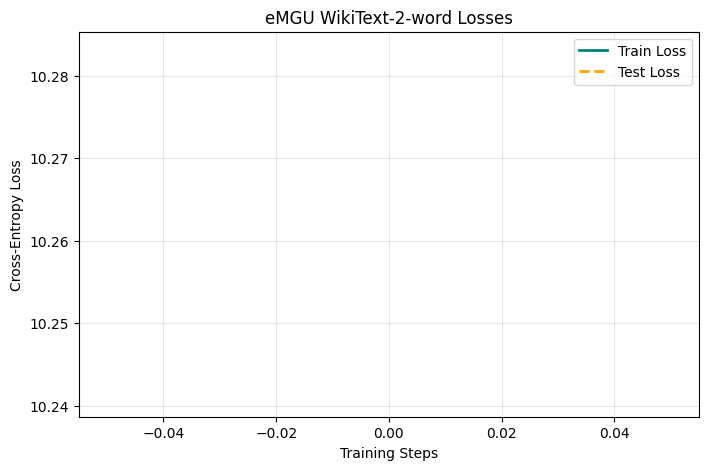

Step: 0
Training loss: 10.283190727233887
Validation loss: 10.240767644001888
PPL measurement: 28022.629074920525


  0%|          | 0/104 [00:00<?, ?it/s]

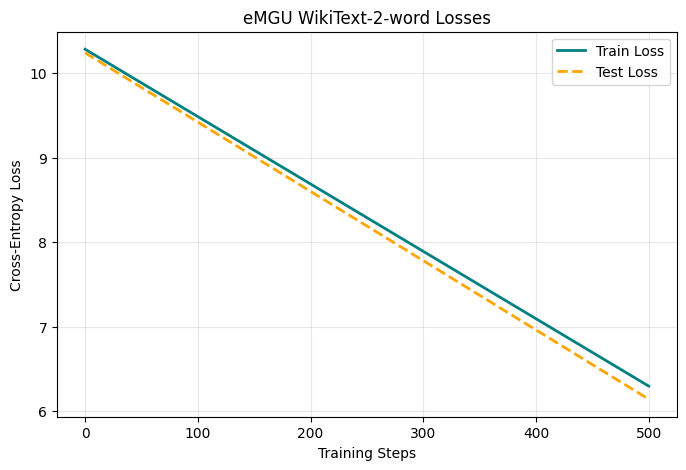

Step: 500
Training loss: 6.295126914978027
Validation loss: 6.1398298511138325
PPL measurement: 463.9746193780163


  0%|          | 0/104 [00:00<?, ?it/s]

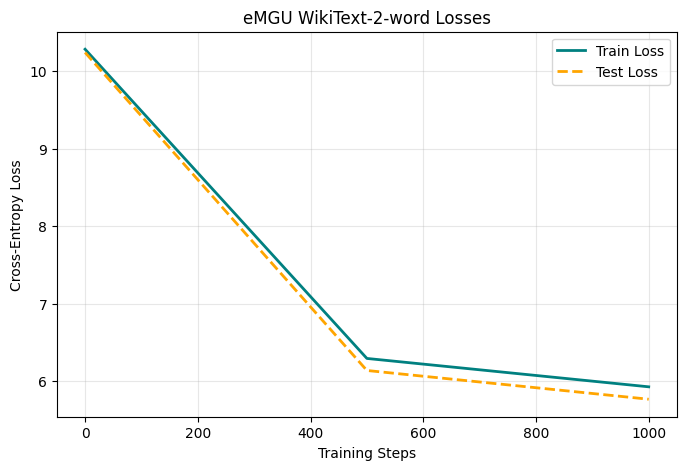

Step: 1000
Training loss: 5.929125785827637
Validation loss: 5.769172402528616
PPL measurement: 320.2725661710217


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

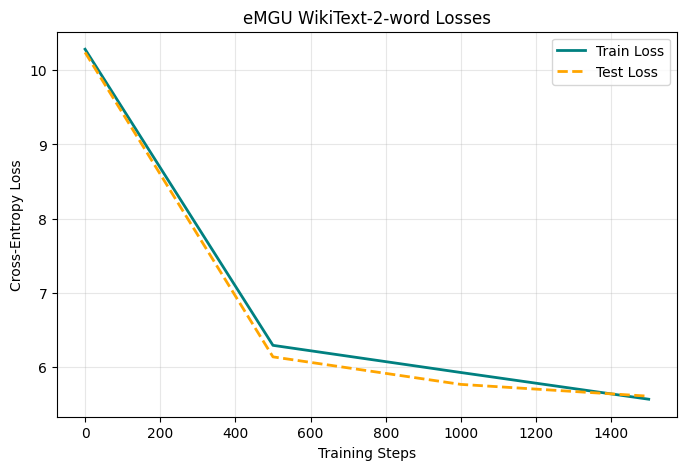

Step: 1500
Training loss: 5.569350719451904
Validation loss: 5.610029766192803
PPL measurement: 273.15236858981604


  0%|          | 0/104 [00:00<?, ?it/s]

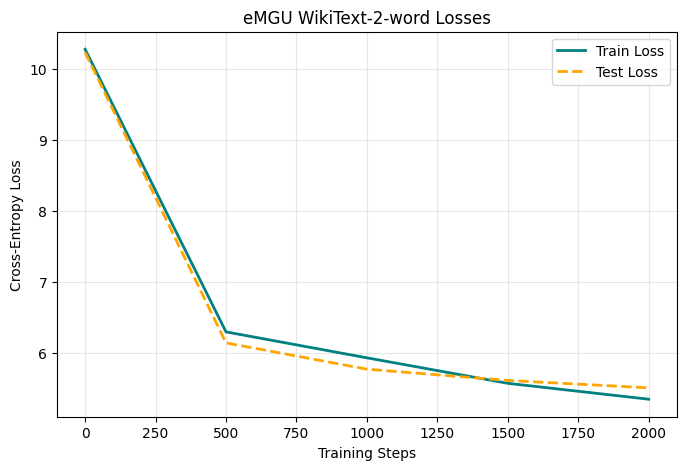

Step: 2000
Training loss: 5.345065116882324
Validation loss: 5.5054391989341145
PPL measurement: 246.02648652421468


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

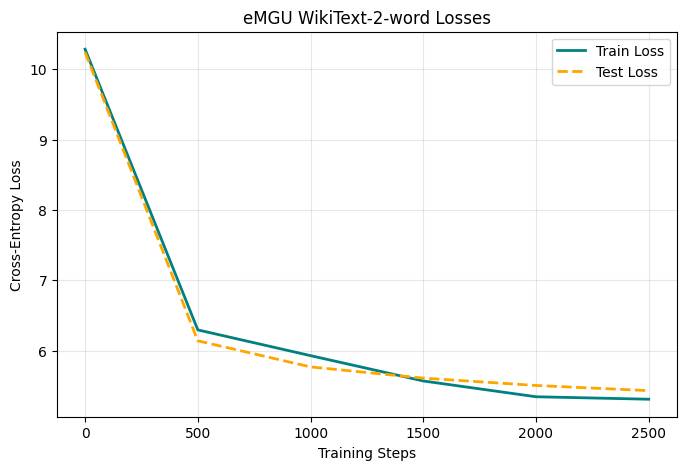

Step: 2500
Training loss: 5.3100385665893555
Validation loss: 5.431745327436007
PPL measurement: 228.5477882542457


  0%|          | 0/104 [00:00<?, ?it/s]

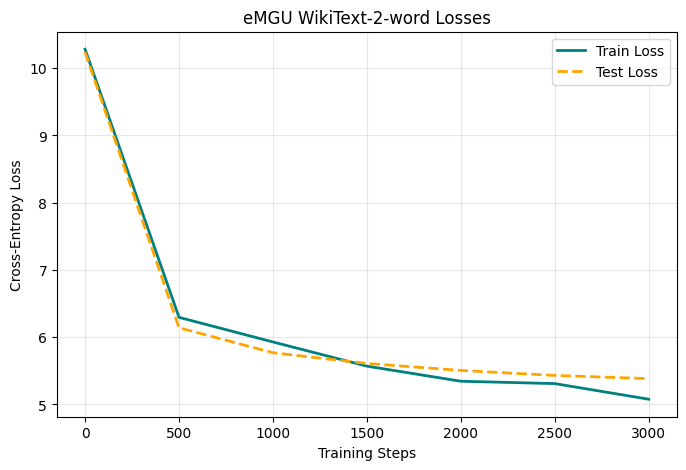

Step: 3000
Training loss: 5.077600479125977
Validation loss: 5.3838618993759155
PPL measurement: 217.862014064361


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

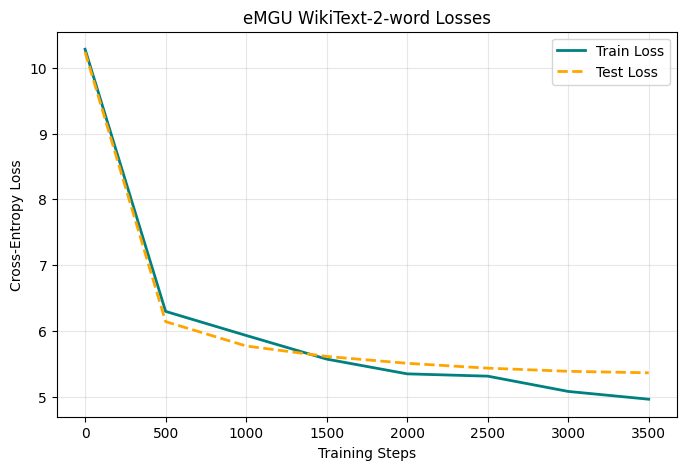

Step: 3500
Training loss: 4.959077835083008
Validation loss: 5.360767827584193
PPL measurement: 212.88834525430374


  0%|          | 0/104 [00:00<?, ?it/s]

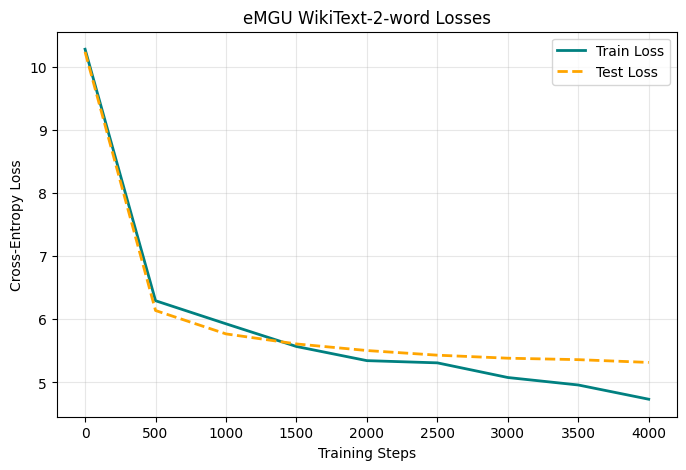

Step: 4000
Training loss: 4.733331203460693
Validation loss: 5.316657790770898
PPL measurement: 203.70192854664793


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

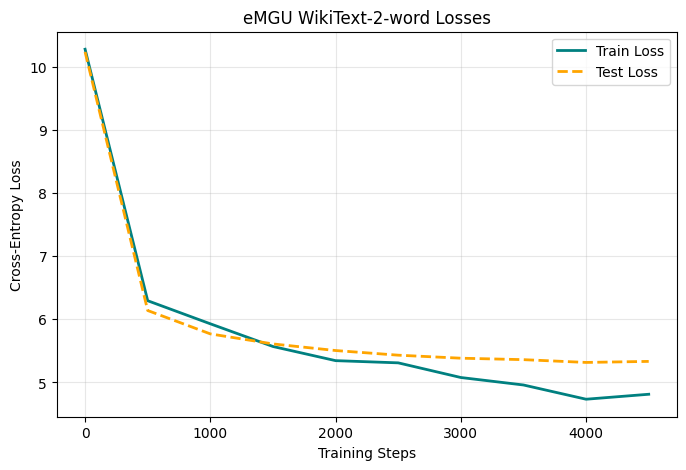

Step: 4500
Training loss: 4.8120880126953125
Validation loss: 5.3331135007051325
PPL measurement: 207.0817205668279


  0%|          | 0/104 [00:00<?, ?it/s]

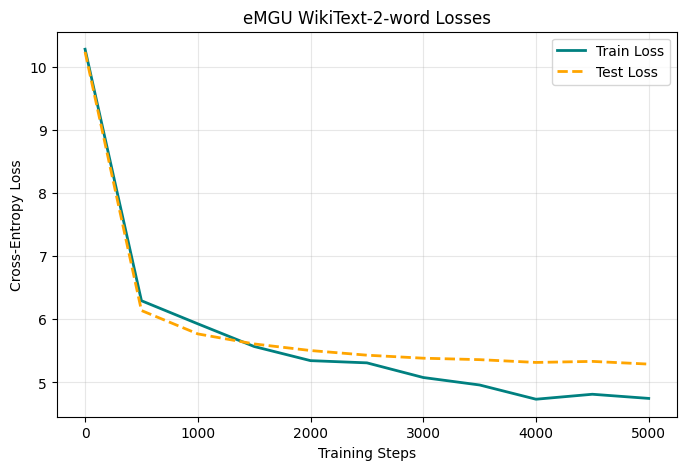

Step: 5000
Training loss: 4.74626350402832
Validation loss: 5.290161256606762
PPL measurement: 198.37541217610567


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

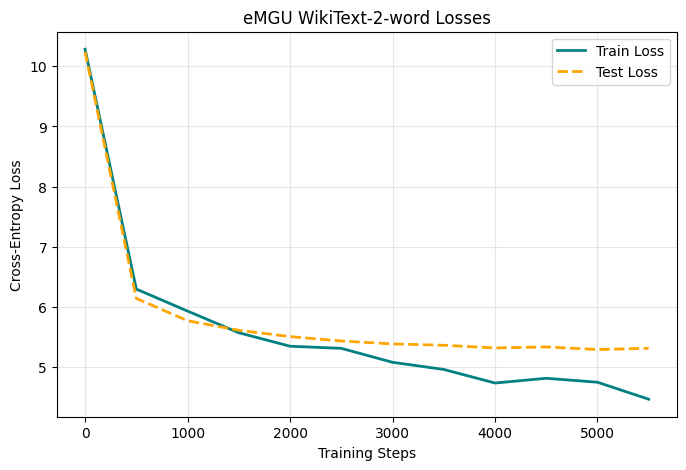

Step: 5500
Training loss: 4.463913917541504
Validation loss: 5.310579900558178
PPL measurement: 202.46760542875364


  0%|          | 0/104 [00:00<?, ?it/s]

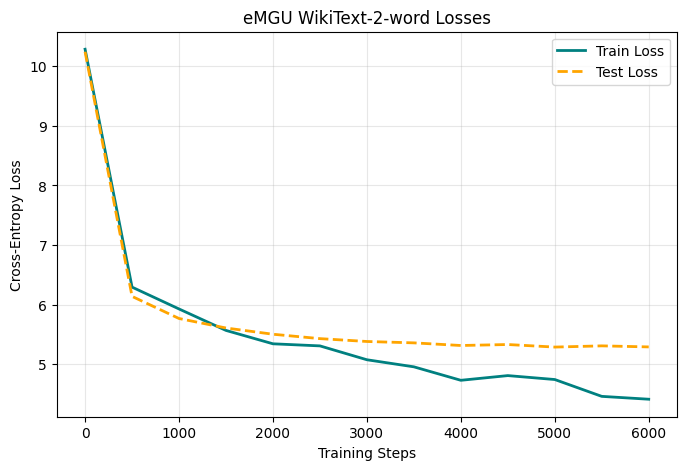

Step: 6000
Training loss: 4.416073322296143
Validation loss: 5.2928279638290405
PPL measurement: 198.90512730414224


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

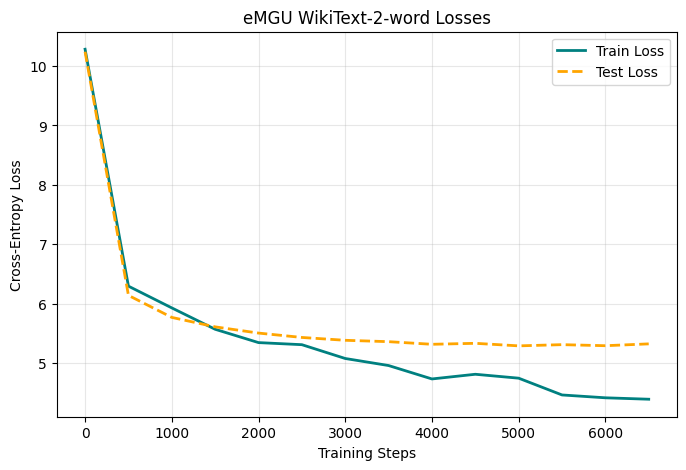

Step: 6500
Training loss: 4.392040252685547
Validation loss: 5.323675247339102
PPL measurement: 205.13642535583608


  0%|          | 0/104 [00:00<?, ?it/s]

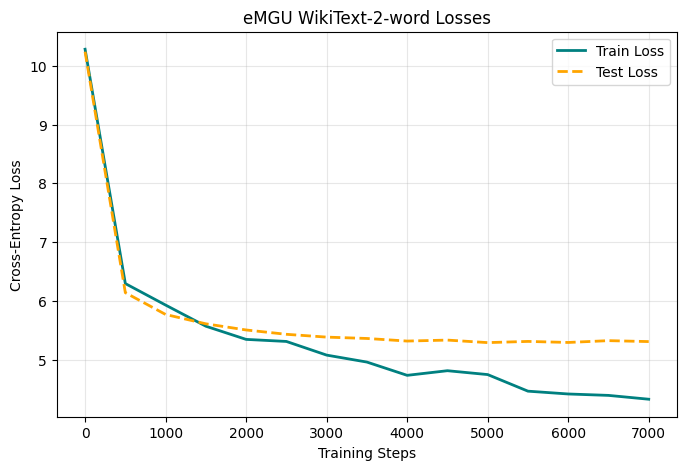

Step: 7000
Training loss: 4.326851844787598
Validation loss: 5.307782131891984
PPL measurement: 201.90193957644382


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

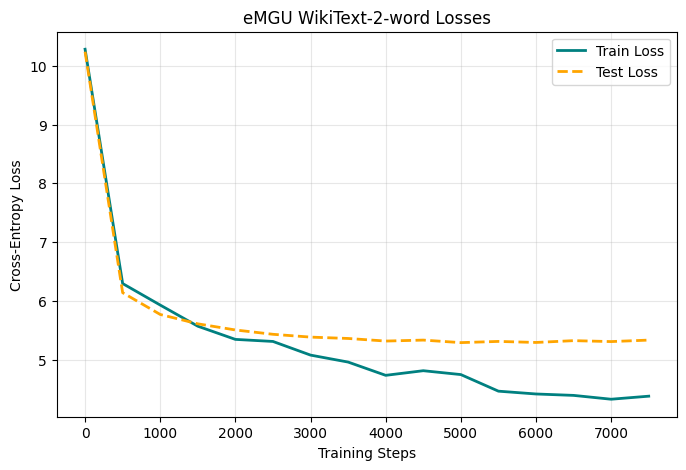

Step: 7500
Training loss: 4.3786492347717285
Validation loss: 5.333072616503789
PPL measurement: 207.07325436913774


  0%|          | 0/104 [00:00<?, ?it/s]

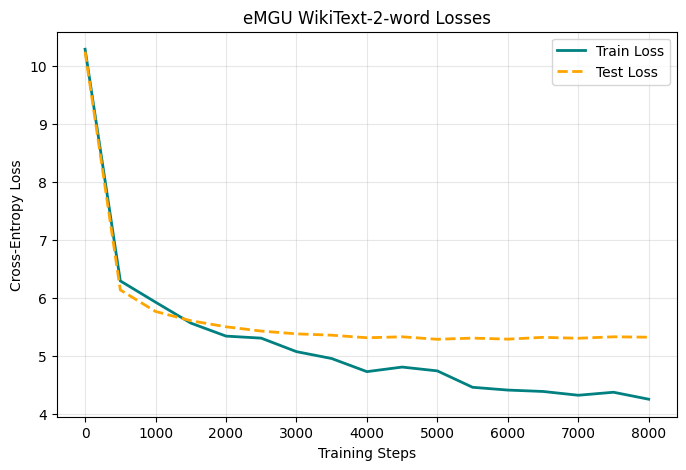

Step: 8000
Training loss: 4.258538722991943
Validation loss: 5.326374269448793
PPL measurement: 205.69084095679355


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

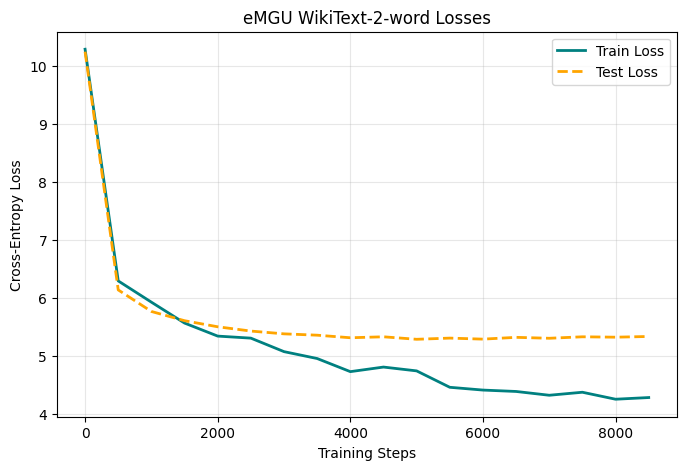

Step: 8500
Training loss: 4.287455081939697
Validation loss: 5.338681564881251
PPL measurement: 208.23798095534275


  0%|          | 0/104 [00:00<?, ?it/s]

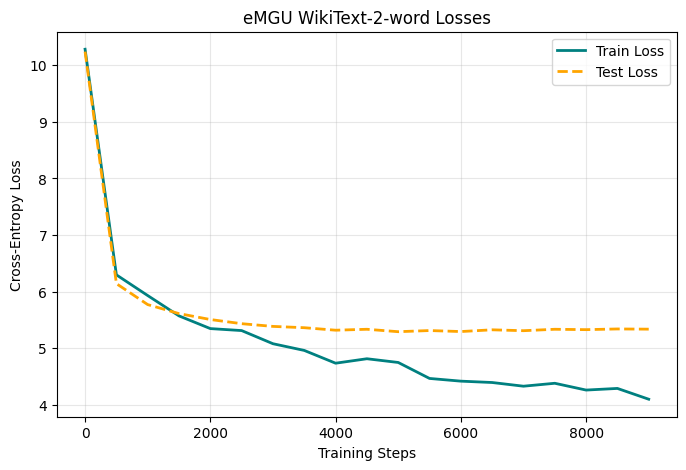

Step: 9000
Training loss: 4.096657752990723
Validation loss: 5.33504254084367
PPL measurement: 207.48157506144884


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

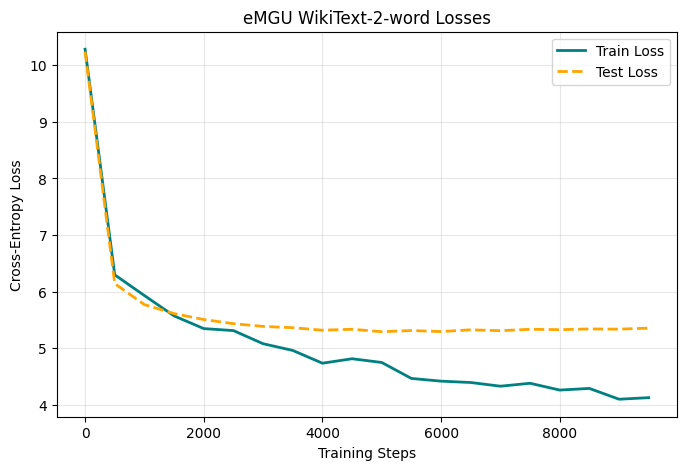

Step: 9500
Training loss: 4.124379634857178
Validation loss: 5.353417699153606
PPL measurement: 211.3293250932671


  0%|          | 0/104 [00:00<?, ?it/s]

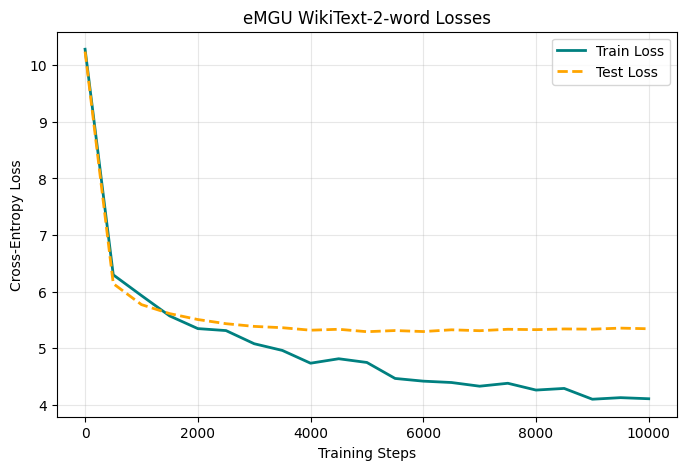

Step: 10000
Training loss: 4.105177879333496
Validation loss: 5.3421512842178345
PPL measurement: 208.96176323903558


In [ ]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




eMGU_model = custom_models_for_lm.eMGU(vocab, hid, emb, device='cuda')
opt_eMGU = torch.optim.Adam(eMGU_model.parameters(), lr=lr)
hid_state = eMGU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(11, epochs+11):

    start_step = train_model_hid_state(
        model=eMGU_model,
        model_name="eMGU",
        hid_state=hid_state,
        opt=opt_eMGU,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

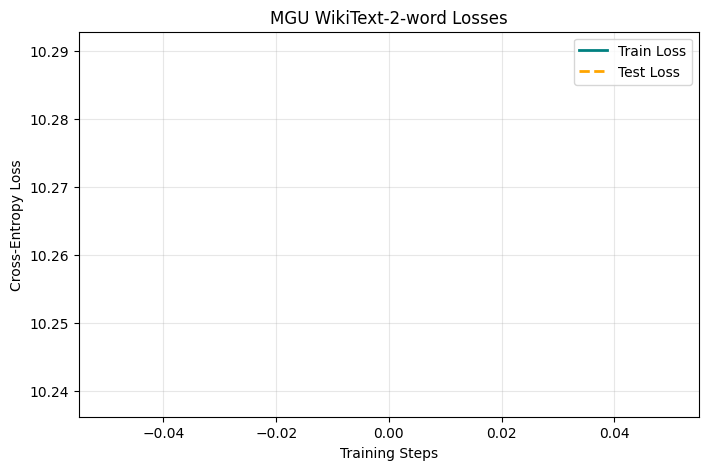

Step: 0
Training loss: 10.290276527404785
Validation loss: 10.238763249837435
PPL measurement: 27966.516934939402


  0%|          | 0/104 [00:00<?, ?it/s]

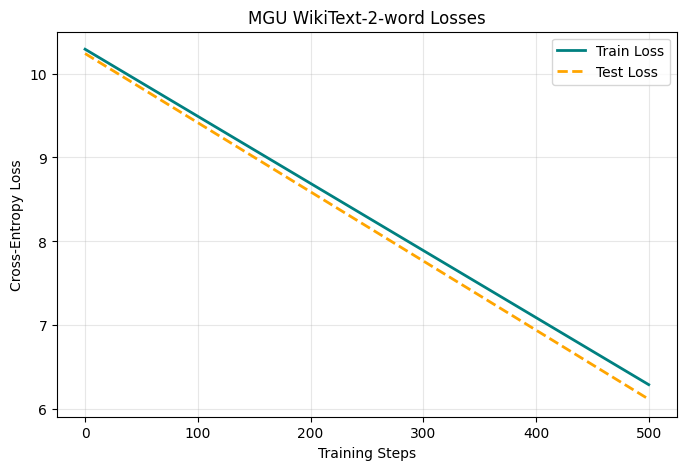

Step: 500
Training loss: 6.292719841003418
Validation loss: 6.119163925831135
PPL measurement: 454.4845528135911


  0%|          | 0/104 [00:00<?, ?it/s]

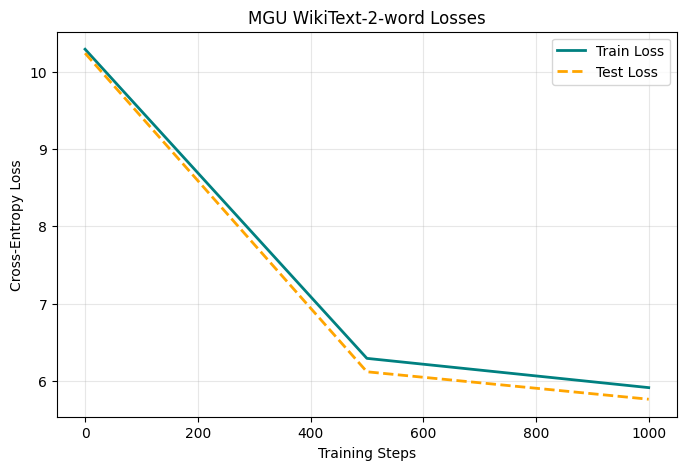

Step: 1000
Training loss: 5.914273738861084
Validation loss: 5.764370248867915
PPL measurement: 318.73825504238334


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

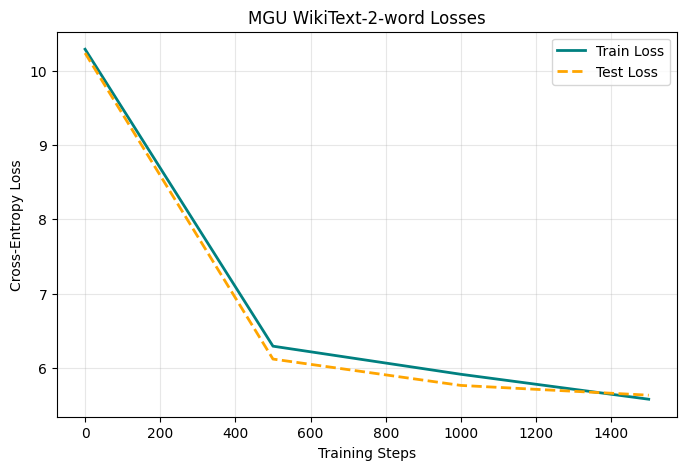

Step: 1500
Training loss: 5.578505039215088
Validation loss: 5.632823270100814
PPL measurement: 279.44996769141994


  0%|          | 0/104 [00:00<?, ?it/s]

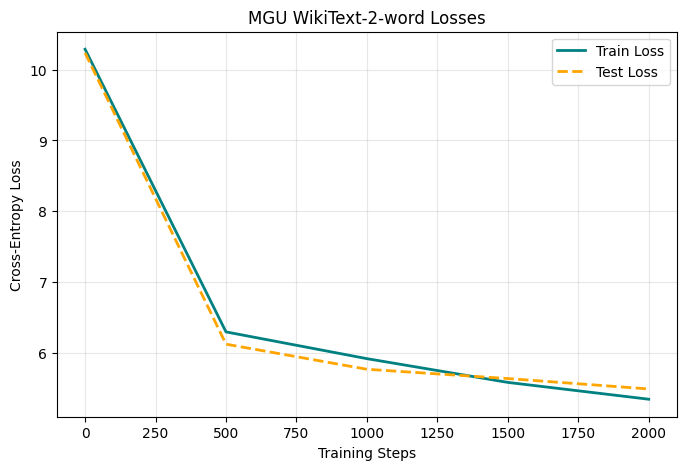

Step: 2000
Training loss: 5.3405609130859375
Validation loss: 5.485685394360469
PPL measurement: 241.21421421600843


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

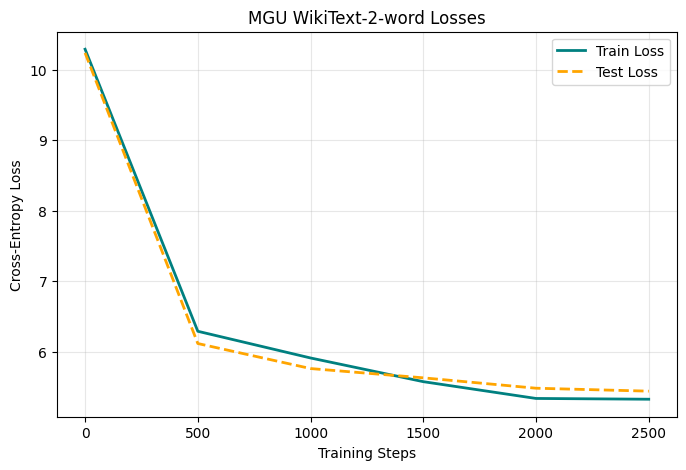

Step: 2500
Training loss: 5.329657554626465
Validation loss: 5.444010436534882
PPL measurement: 231.36821286228593


  0%|          | 0/104 [00:00<?, ?it/s]

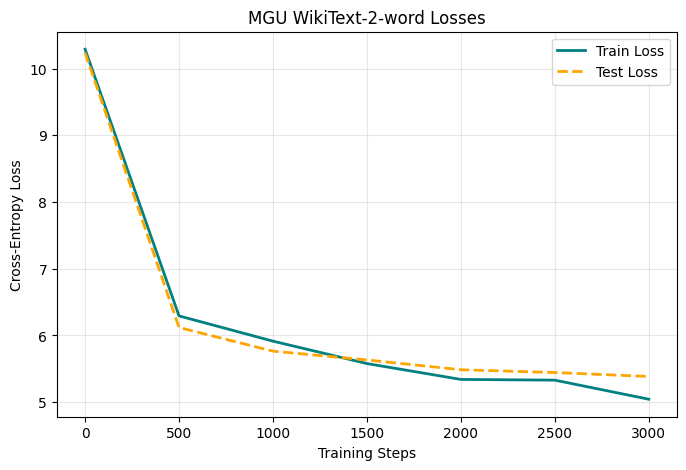

Step: 3000
Training loss: 5.0438079833984375
Validation loss: 5.384629570520842
PPL measurement: 218.02932465767444


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

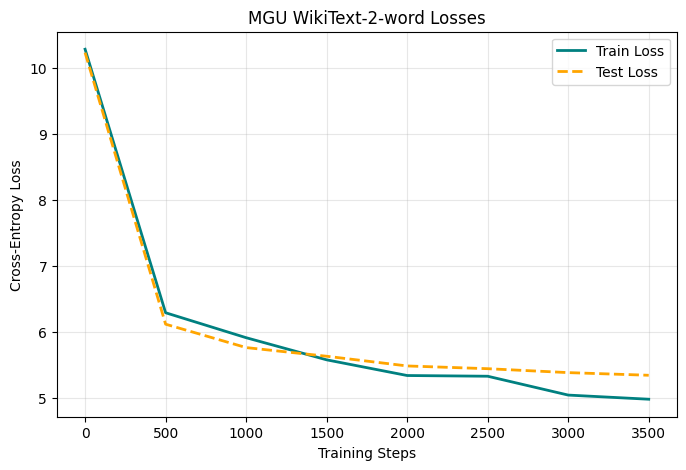

Step: 3500
Training loss: 4.980944633483887
Validation loss: 5.344242146381965
PPL measurement: 209.39913056159858


  0%|          | 0/104 [00:00<?, ?it/s]

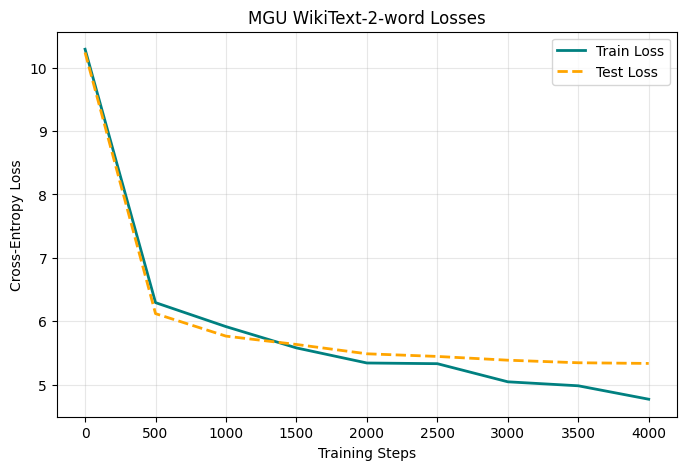

Step: 4000
Training loss: 4.769029140472412
Validation loss: 5.3335388256953316
PPL measurement: 207.16981633093536


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

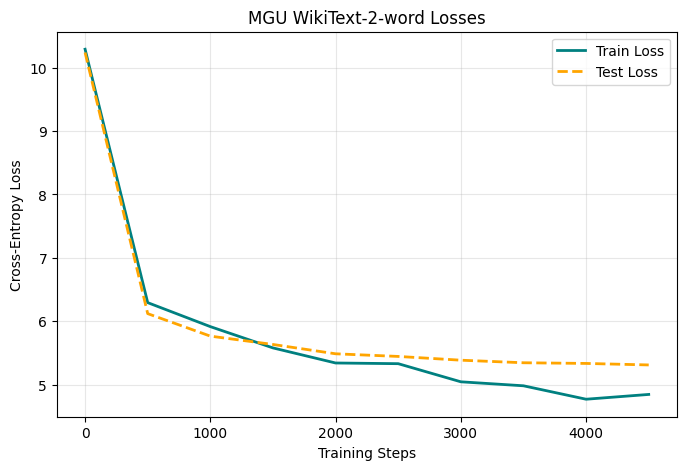

Step: 4500
Training loss: 4.844607353210449
Validation loss: 5.309754729270935
PPL measurement: 202.30060388607203


  0%|          | 0/104 [00:00<?, ?it/s]

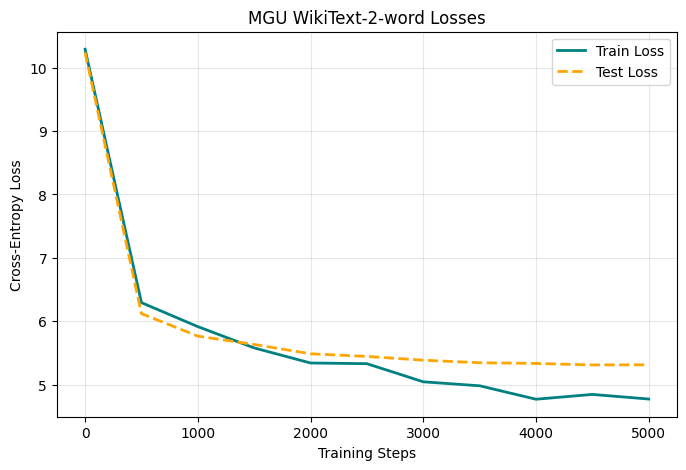

Step: 5000
Training loss: 4.771860122680664
Validation loss: 5.312350066808554
PPL measurement: 202.82632415289734


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

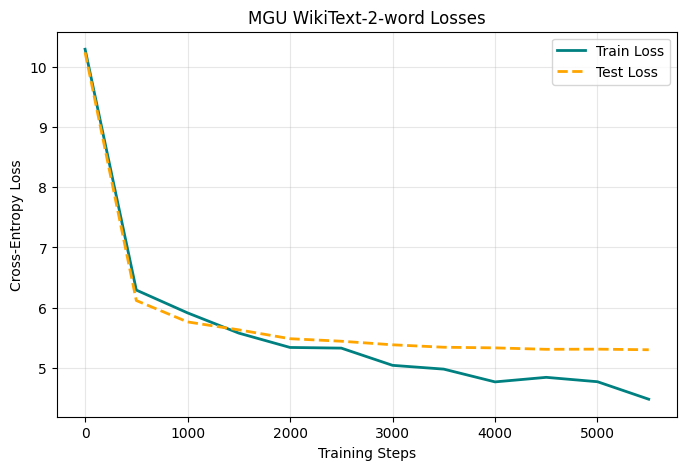

Step: 5500
Training loss: 4.481401443481445
Validation loss: 5.302444966939779
PPL measurement: 200.8272261333447


  0%|          | 0/104 [00:00<?, ?it/s]

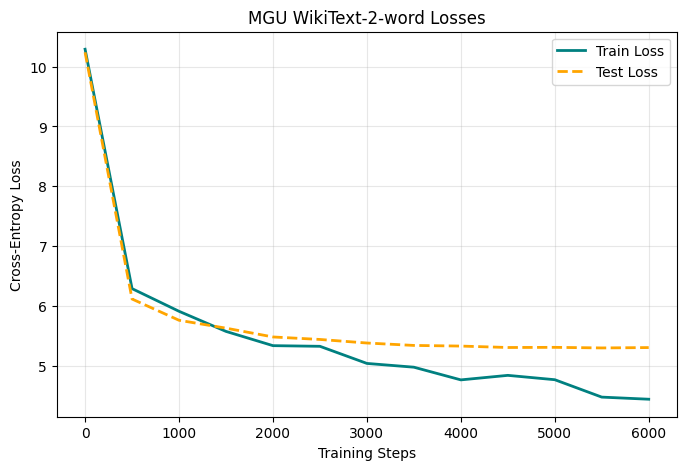

Step: 6000
Training loss: 4.44609260559082
Validation loss: 5.308638820281396
PPL measurement: 202.07498073447107


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

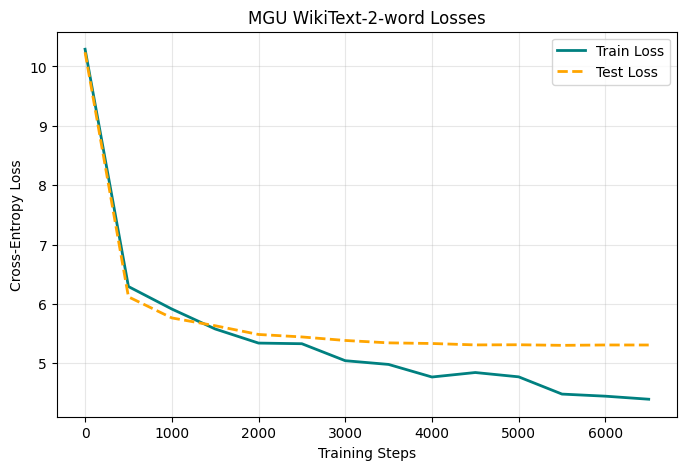

Step: 6500
Training loss: 4.3948750495910645
Validation loss: 5.308153308354891
PPL measurement: 201.97689473416446


  0%|          | 0/104 [00:00<?, ?it/s]

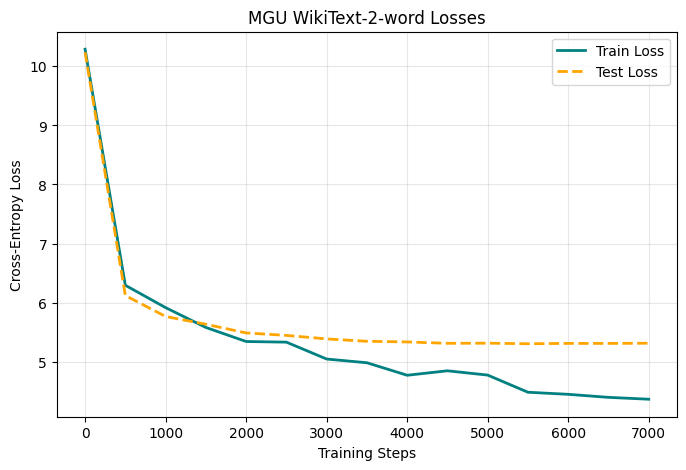

Step: 7000
Training loss: 4.363178253173828
Validation loss: 5.311624641601856
PPL measurement: 202.6792421797105


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

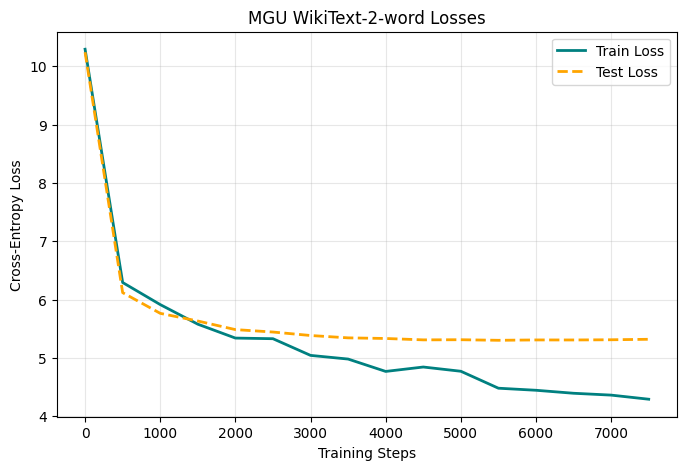

Step: 7500
Training loss: 4.292724132537842
Validation loss: 5.319687054707454
PPL measurement: 204.3199310263249


  0%|          | 0/104 [00:00<?, ?it/s]

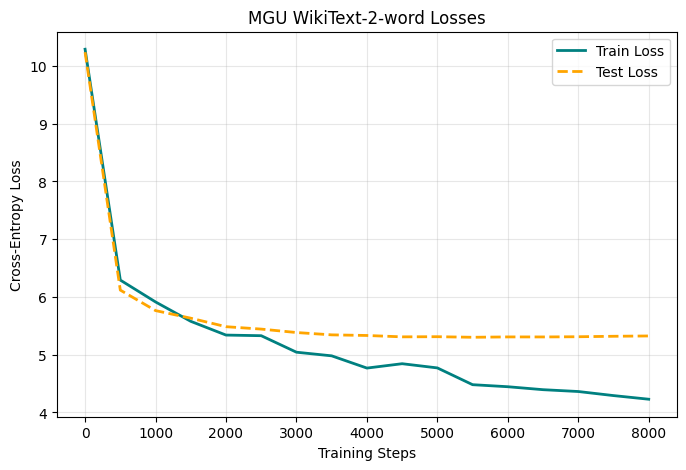

Step: 8000
Training loss: 4.229731559753418
Validation loss: 5.325176564546732
PPL measurement: 205.44463150083885


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

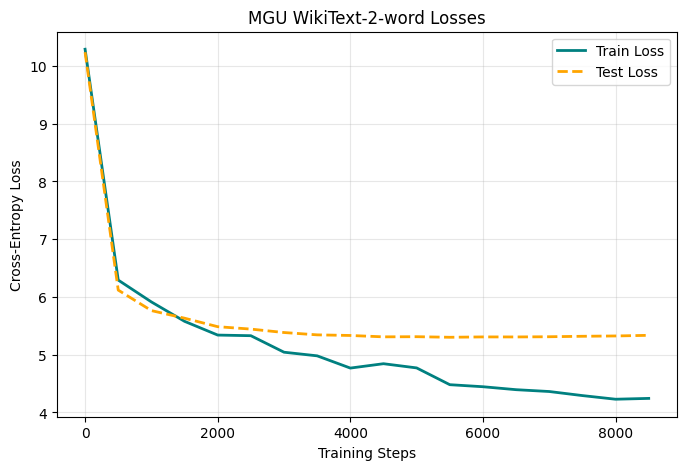

Step: 8500
Training loss: 4.244016170501709
Validation loss: 5.336087346076965
PPL measurement: 207.69846618164394


  0%|          | 0/104 [00:00<?, ?it/s]

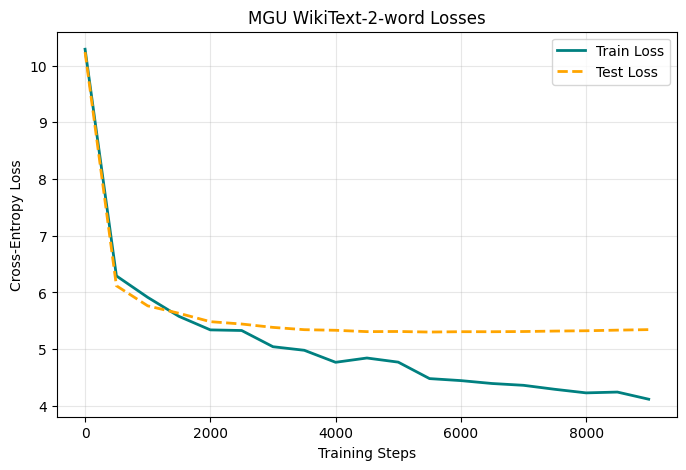

Step: 9000
Training loss: 4.117771625518799
Validation loss: 5.3453281384248
PPL measurement: 209.6266598763158


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

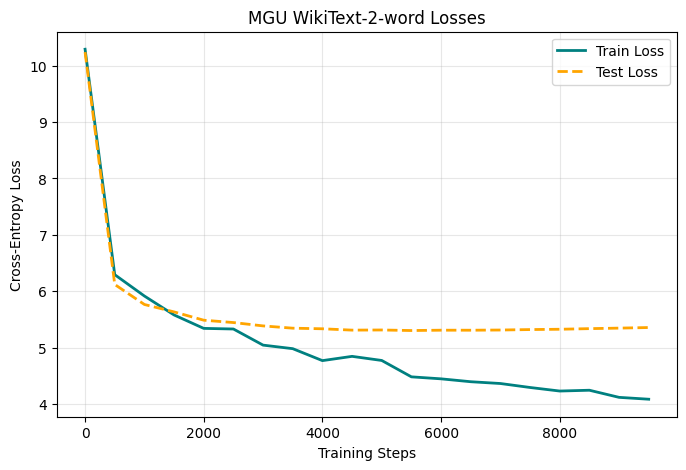

Step: 9500
Training loss: 4.084645748138428
Validation loss: 5.355840756342961
PPL measurement: 211.84200901414664


  0%|          | 0/104 [00:00<?, ?it/s]

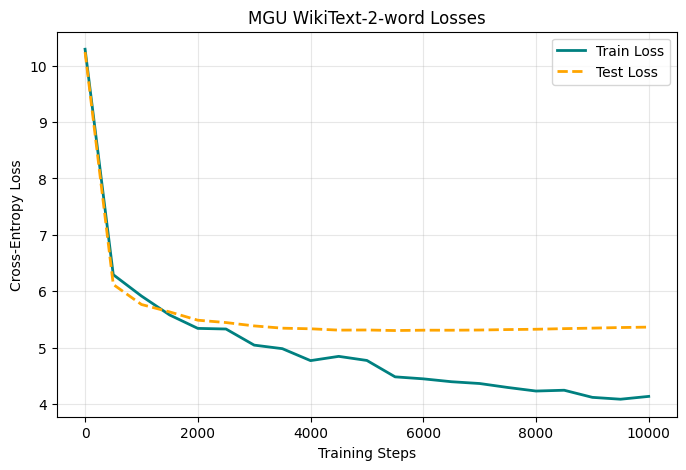

Step: 10000
Training loss: 4.13480806350708
Validation loss: 5.363197308320266
PPL measurement: 213.40618217073418


In [17]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




MGU_model = custom_models_for_lm.MGU(vocab, hid, emb, device='cuda')
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)
hid_state = MGU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(epochs):

    start_step = train_model_hid_state(
        model=MGU_model,
        model_name="MGU",
        hid_state=hid_state,
        opt=opt_MGU,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

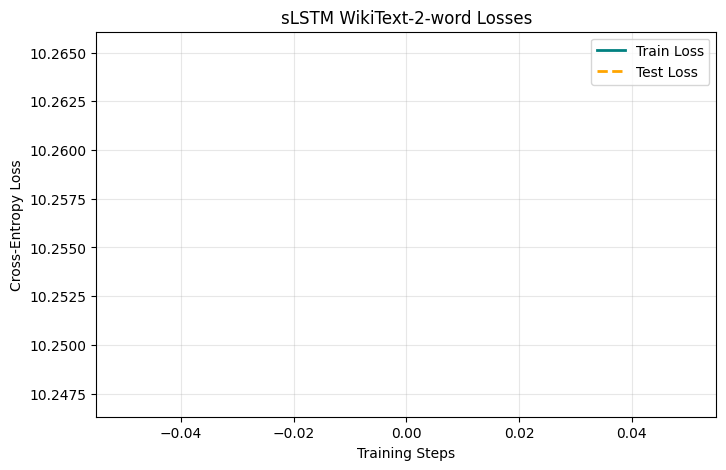

Step: 0
Training loss: 10.265172004699707
Validation loss: 10.247213125228882
PPL measurement: 28203.831746436037


  0%|          | 0/104 [00:00<?, ?it/s]

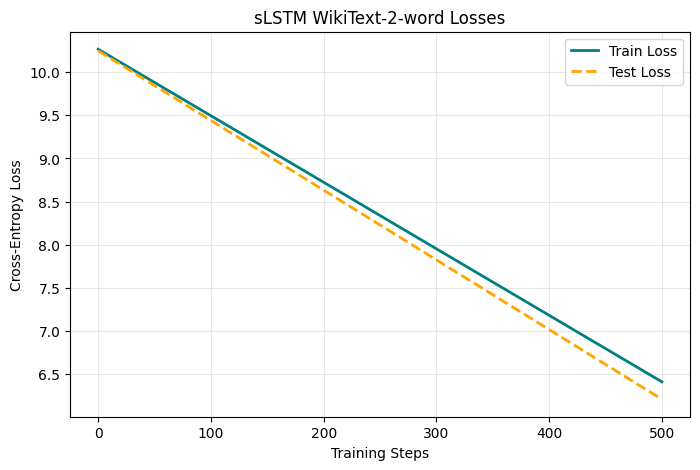

Step: 500
Training loss: 6.41253662109375
Validation loss: 6.210971222474025
PPL measurement: 498.1848647375181


  0%|          | 0/104 [00:00<?, ?it/s]

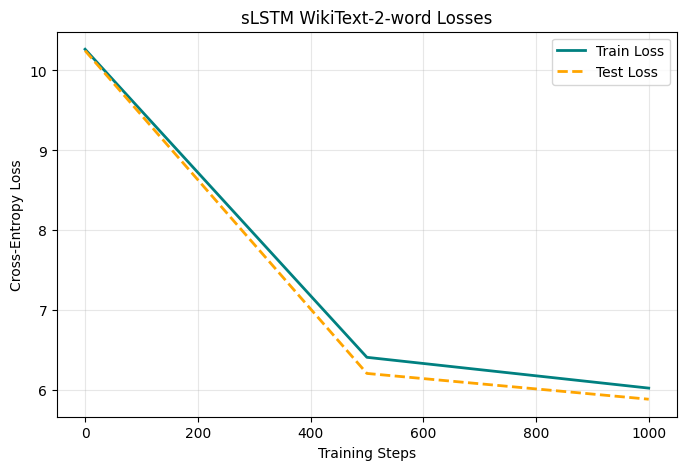

Step: 1000
Training loss: 6.027393341064453
Validation loss: 5.88852489911593
PPL measurement: 360.87256811950425


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

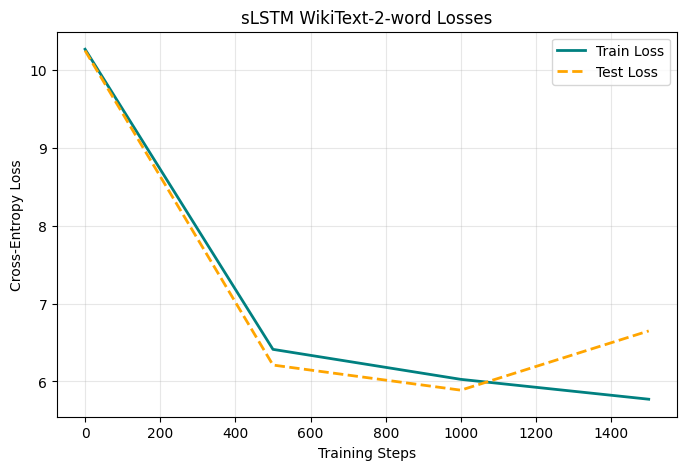

Step: 1500
Training loss: 5.772336959838867
Validation loss: 6.649212649235358
PPL measurement: 772.1761126753869


  0%|          | 0/104 [00:00<?, ?it/s]

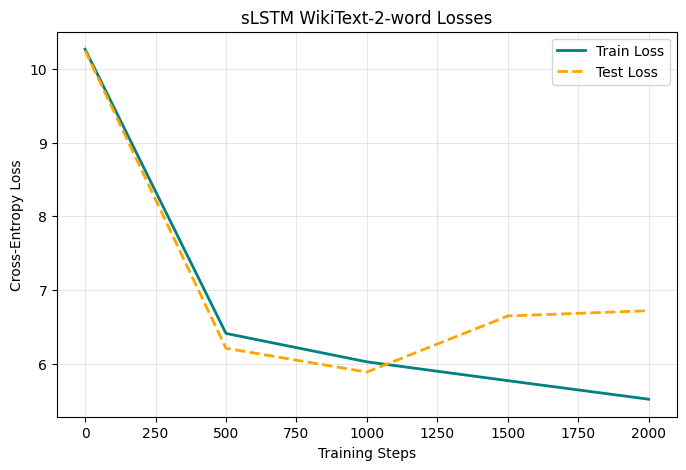

Step: 2000
Training loss: 5.520750045776367
Validation loss: 6.720892663185413
PPL measurement: 829.5576966802827


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

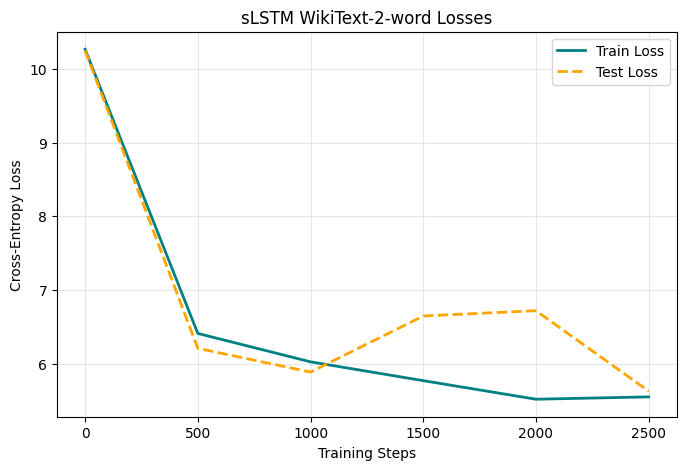

Step: 2500
Training loss: 5.552563667297363
Validation loss: 5.629779499310714
PPL measurement: 278.6006792178793


  0%|          | 0/104 [00:00<?, ?it/s]

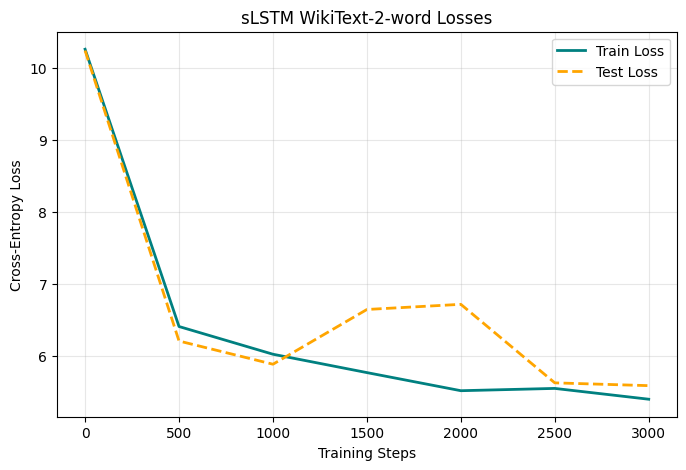

Step: 3000
Training loss: 5.402408599853516
Validation loss: 5.591013312339783
PPL measurement: 268.0070570230639


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

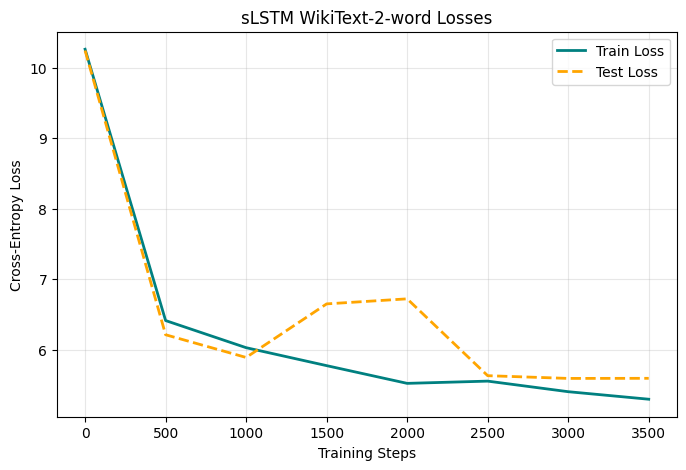

Step: 3500
Training loss: 5.2955827713012695
Validation loss: 5.592412256277525
PPL measurement: 268.382246243913


  0%|          | 0/104 [00:00<?, ?it/s]

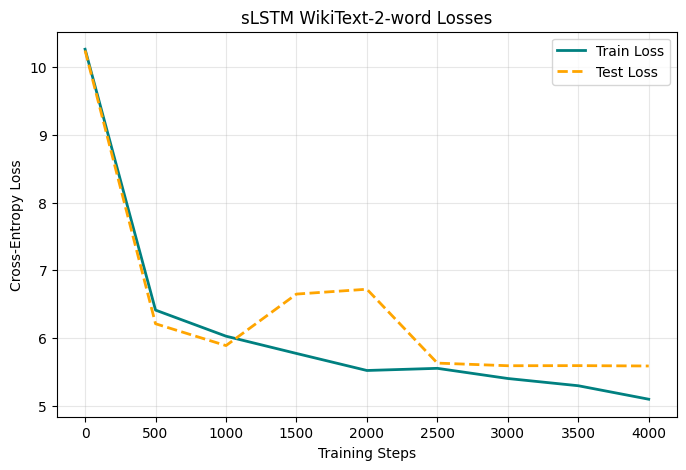

Step: 4000
Training loss: 5.0964131355285645
Validation loss: 5.587200371118692
PPL measurement: 266.98710760709605


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

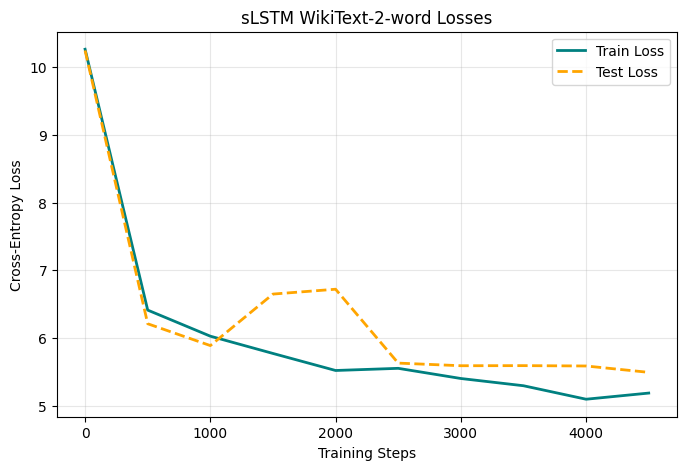

Step: 4500
Training loss: 5.187241077423096
Validation loss: 5.493258774280548
PPL measurement: 243.04795614988038


  0%|          | 0/104 [00:00<?, ?it/s]

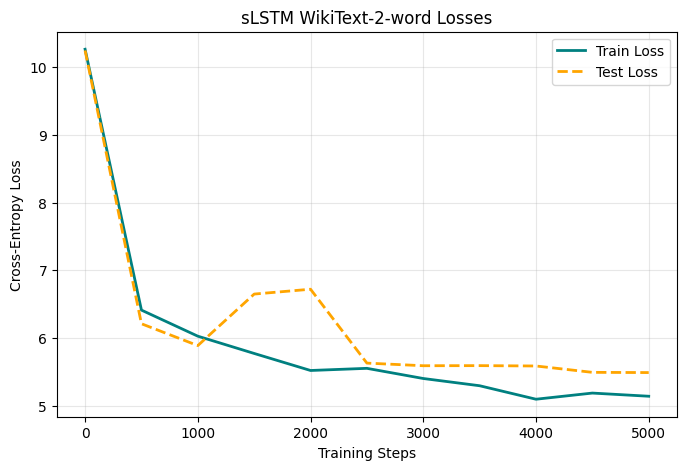

Step: 5000
Training loss: 5.140467166900635
Validation loss: 5.489994044487293
PPL measurement: 242.25576409637654


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

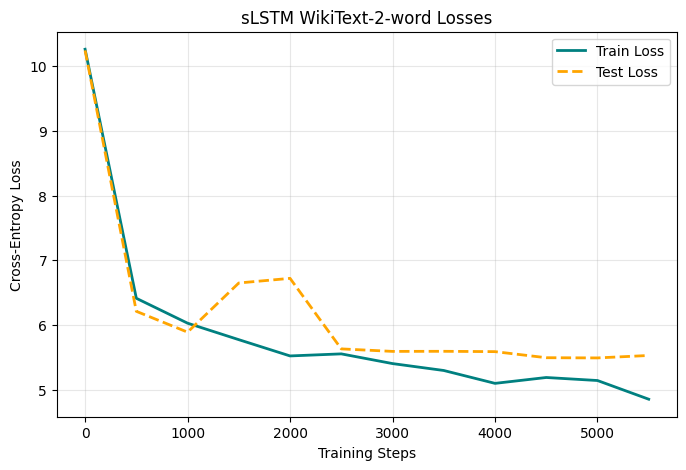

Step: 5500
Training loss: 4.851134777069092
Validation loss: 5.527932767684643
PPL measurement: 251.62320937359573


  0%|          | 0/104 [00:00<?, ?it/s]

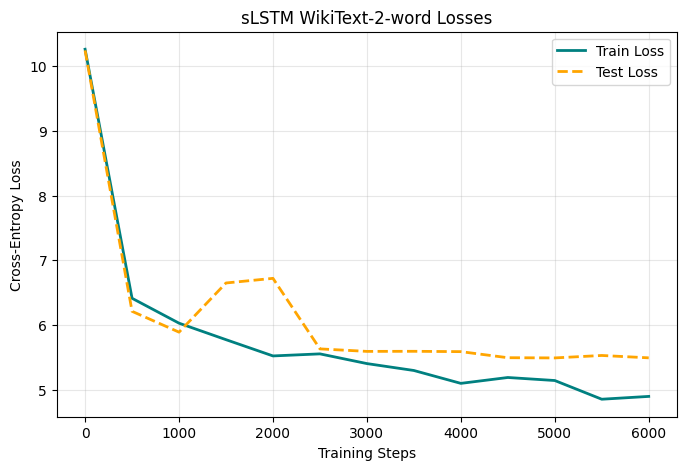

Step: 6000
Training loss: 4.8947553634643555
Validation loss: 5.491212303821857
PPL measurement: 242.55107428801384


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

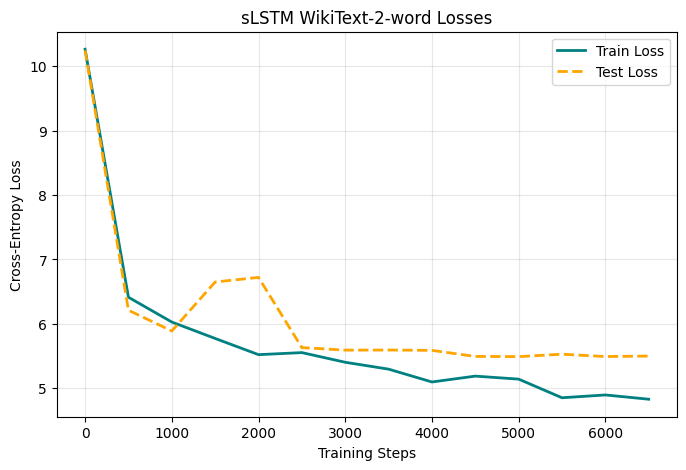

Step: 6500
Training loss: 4.828447341918945
Validation loss: 5.498876324066749
PPL measurement: 244.41713225086968


  0%|          | 0/104 [00:00<?, ?it/s]

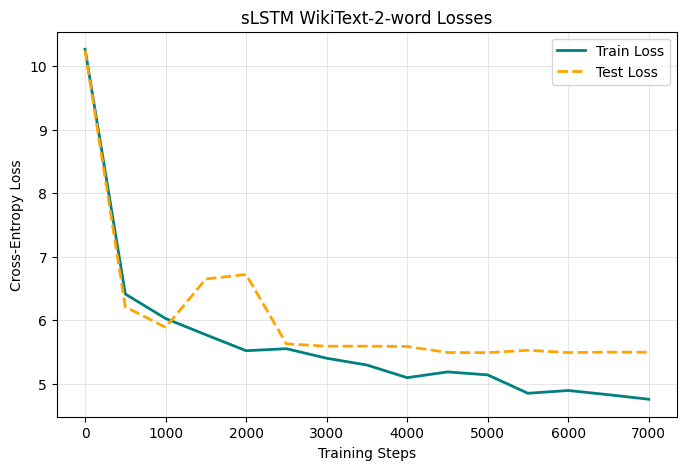

Step: 7000
Training loss: 4.757524013519287
Validation loss: 5.496235742018773
PPL measurement: 243.77258013013076


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

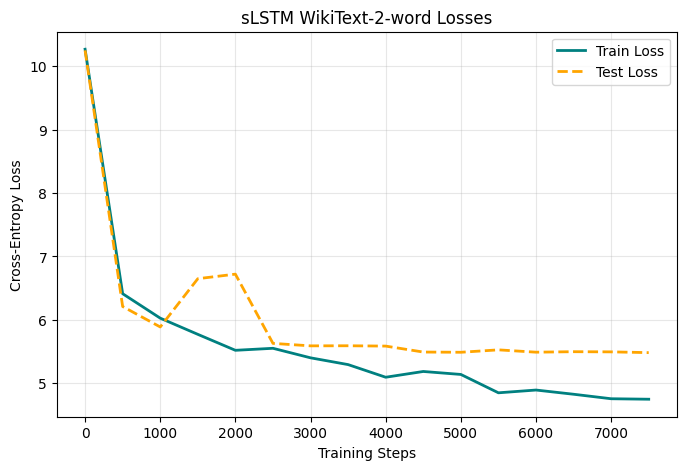

Step: 7500
Training loss: 4.750040054321289
Validation loss: 5.484168203977438
PPL measurement: 240.84852381107984


  0%|          | 0/104 [00:00<?, ?it/s]

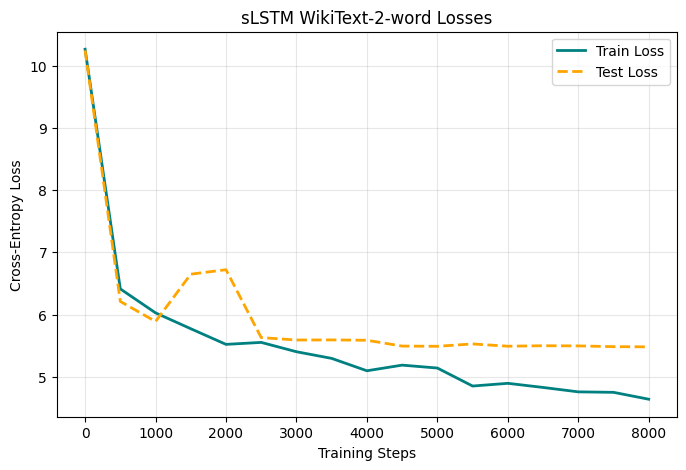

Step: 8000
Training loss: 4.639192581176758
Validation loss: 5.480841384484218
PPL measurement: 240.048595593328


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

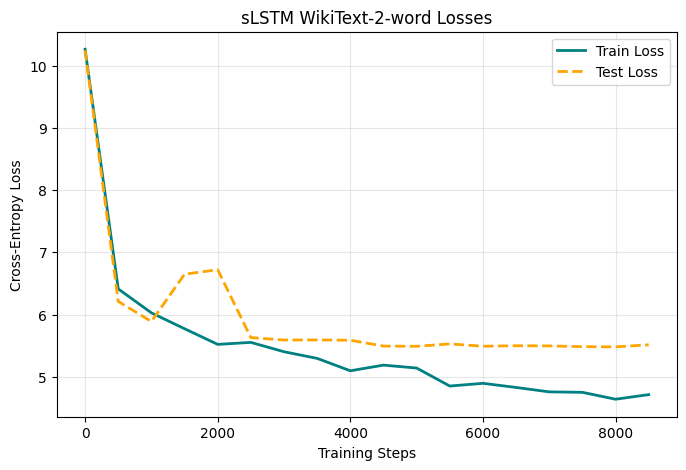

Step: 8500
Training loss: 4.71312141418457
Validation loss: 5.5137654818021336
PPL measurement: 248.08352450006217


  0%|          | 0/104 [00:00<?, ?it/s]

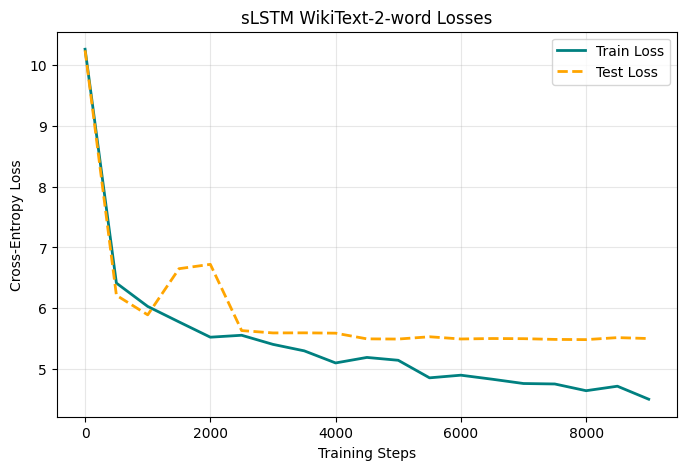

Step: 9000
Training loss: 4.4987592697143555
Validation loss: 5.498727074036231
PPL measurement: 244.38065570855244


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

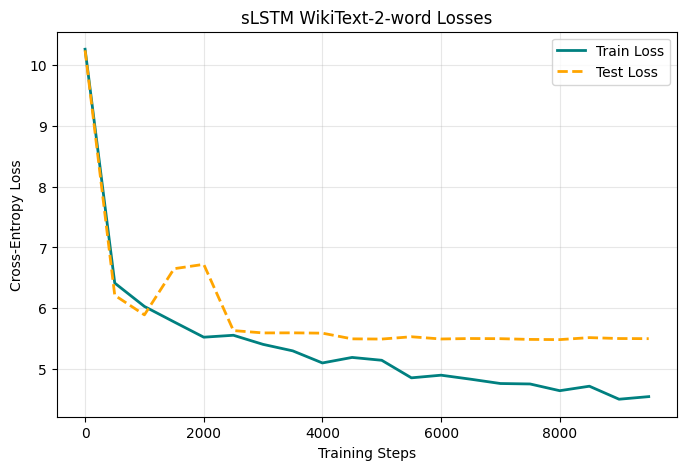

Step: 9500
Training loss: 4.541562557220459
Validation loss: 5.496573053873503
PPL measurement: 243.85482138096134


  0%|          | 0/104 [00:00<?, ?it/s]

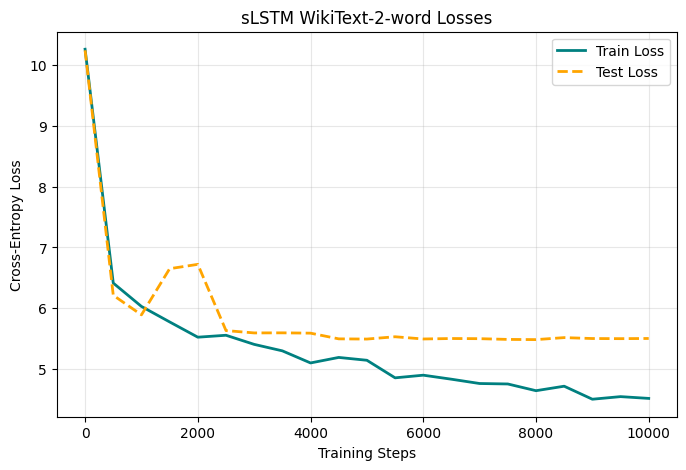

Step: 10000
Training loss: 4.5122151374816895
Validation loss: 5.499637947632716
PPL measurement: 244.60335700629733


In [18]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




sLSTM_model = custom_models_for_lm.sLSTM(vocab, hid, emb, device='cuda')
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)
cell_state = sLSTM_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(epochs):

    start_step = train_model(
        model=sLSTM_model,
        model_name="sLSTM",
        cell_state=cell_state,
        opt=opt_sLSTM,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


## Testing

In [19]:
def evaluate_model(model, encoded_data, hid, device):
    cell_state = model.init_hid.unsqueeze(0).expand(batch_size, -1)
    m = torch.zeros((batch_size, hid), device=device)
    norm = torch.ones((batch_size, hid), device=device)

    model.eval()
    with torch.no_grad():

        loss_sum = 0

        for i in trange(len(encoded_data)):
            is_last_chunk = (i == (len(encoded_data)-1))
            chunk = encoded_data[i]

            inputs = torch.tensor(chunk, device=device)
            if not is_last_chunk:
                pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
                next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
                outputs = next_token[:, 1:]
            else:
                outputs = inputs[:, 1:]

            logits, cell_state, m, norm = model.forward(cell_state, m, norm, inputs)
            if is_last_chunk:
                logits = logits[:, :-1]
            loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)

            loss_sum = loss_sum + loss_t.item()


        loss_avg = loss_sum/len(encoded_data)
        ppl_avg = math.exp(loss_avg)
        
    model.train()

    return loss_avg, ppl_avg
def evaluate_model_hid_state(model, encoded_data, hid, device):
    loc_hid_state = model.init_hid.unsqueeze(0).expand(batch_size, -1)
    model.eval()
    with torch.no_grad():

        loss_sum = 0

        for i in trange(len(encoded_data)):
            is_last_chunk = (i == (len(encoded_data)-1))
            chunk = encoded_data[i]

            inputs = torch.tensor(chunk, device=device)
            if not is_last_chunk:
                pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
                next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
                outputs = next_token[:, 1:]
            else:
                outputs = inputs[:, 1:]

            logits, loc_hid_state = model.forward(loc_hid_state, inputs)
            if is_last_chunk:
                logits = logits[:, :-1]
            loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)

            loss_sum = loss_sum + loss_t.item()


        loss_avg = loss_sum/len(encoded_data)
        ppl_avg = math.exp(loss_avg)
        
    model.train()

    return loss_avg, ppl_avg

In [20]:
def test_ppl_by_epochs(model_name, source_architecture, source_opt, hid, eval_data, device, eval_func):

    best_ppl = 33000
    best_epoch=0

    ppl_history = []

    for i in range(1, 11):
        epoch = i*1000
        _ = load_model(
            filename=f"{model_name}_wikitext2_epoch_{epoch}.pt",
            device=device,
            model=source_architecture,
            optimizer=source_opt
        )
    
        loss_avg, ppl_avg = eval_func(
            model=source_architecture,
            encoded_data=eval_data,
            hid=hid,
            device=device
        )

        if ppl_avg < best_ppl:
            best_ppl=ppl_avg
            best_epoch=epoch

        ppl_history.append(ppl_avg)

    for i in range(len(ppl_history)):
        print(f"{model_name} PPL EPOCH {(i+1)*1000} = {ppl_history[i]}")

    print(f"{model_name} BEST PPL at EPOCH {best_epoch} = {best_ppl} ")


In [24]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)

eGRU_model = custom_models_for_lm.eGRU(vocab, hid, emb, device='cuda')
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)
cell_state = eGRU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

test_ppl_by_epochs(
    model_name="eGRU",
    source_architecture=eGRU_model,
    source_opt=opt_eGRU,
    hid=hid,
    eval_data=test_data_chunked,
    device='cuda',
    eval_func=evaluate_model
)


  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

...

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

eGRU PPL EPOCH 1000 = 464.8944983659013
eGRU PPL EPOCH 2000 = 325.6455609629267
eGRU PPL EPOCH 3000 = 741.9636031071778
eGRU PPL EPOCH 4000 = 287.2752969555131
eGRU PPL EPOCH 5000 = 380.4261632614006
eGRU PPL EPOCH 6000 = 260.72346951700706
eGRU PPL EPOCH 7000 = 377.06039362635124
eGRU PPL EPOCH 8000 = 280.02314180260396
eGRU PPL EPOCH 9000 = 445.3403178475523
eGRU PPL EPOCH 10000 = 253.31585829262397
eGRU BEST PPL at EPOCH 10000 = 253.31585829262397 


In [21]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)

sLSTM_model = custom_models_for_lm.sLSTM(vocab, hid, emb, device='cuda')
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)
cell_state = sLSTM_model.init_hid.unsqueeze(0).expand(batch_size, -1)

test_ppl_by_epochs(
    model_name="sLSTM",
    source_architecture=sLSTM_model,
    source_opt=opt_sLSTM,
    hid=hid,
    eval_data=test_data_chunked,
    device='cuda',
    eval_func=evaluate_model
)


  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

...

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

sLSTM PPL EPOCH 1000 = 333.3098926126135
sLSTM PPL EPOCH 2000 = 950.6448435415417
sLSTM PPL EPOCH 3000 = 243.01828988732038
sLSTM PPL EPOCH 4000 = 241.83703346149883
sLSTM PPL EPOCH 5000 = 219.21995126549152
sLSTM PPL EPOCH 6000 = 224.30734226896033
sLSTM PPL EPOCH 7000 = 220.1670482919561
sLSTM PPL EPOCH 8000 = 222.44452249085455
sLSTM PPL EPOCH 9000 = 220.8740771349125
sLSTM PPL EPOCH 10000 = 227.81382928386296
sLSTM BEST PPL at EPOCH 5000 = 219.21995126549152 


In [22]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)

GRU_model = custom_models_for_lm.GRU_LM(vocab, hid, emb, device='cuda')
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)
hid_state = GRU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

test_ppl_by_epochs(
    model_name="GRU",
    source_architecture=GRU_model,
    source_opt=opt_GRU,
    hid=hid,
    eval_data=test_data_chunked,
    device='cuda',
    eval_func=evaluate_model_hid_state
)


  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

...

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

GRU PPL EPOCH 1000 = 305.9255322279792
GRU PPL EPOCH 2000 = 220.8985102500769
GRU PPL EPOCH 3000 = 196.13037740858908
GRU PPL EPOCH 4000 = 182.95480158470937
GRU PPL EPOCH 5000 = 177.9487074926765
GRU PPL EPOCH 6000 = 175.46616034352877
GRU PPL EPOCH 7000 = 176.63211573954825
GRU PPL EPOCH 8000 = 179.59294934191797
GRU PPL EPOCH 9000 = 182.3856387877463
GRU PPL EPOCH 10000 = 184.89262154655464
GRU BEST PPL at EPOCH 6000 = 175.46616034352877 


In [23]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)

MGU_model = custom_models_for_lm.MGU(vocab, hid, emb, device='cuda')
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)
hid_state = MGU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

test_ppl_by_epochs(
    model_name="MGU",
    source_architecture=MGU_model,
    source_opt=opt_MGU,
    hid=hid,
    eval_data=test_data_chunked,
    device='cuda',
    eval_func=evaluate_model_hid_state
)


  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

...

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

MGU PPL EPOCH 1000 = 290.7148800610551
MGU PPL EPOCH 2000 = 216.9232026264272
MGU PPL EPOCH 3000 = 196.41896417865604
MGU PPL EPOCH 4000 = 187.71496695681145
MGU PPL EPOCH 5000 = 184.4122347452931
MGU PPL EPOCH 6000 = 184.754690092308
MGU PPL EPOCH 7000 = 185.86332906207855
MGU PPL EPOCH 8000 = 188.39830431921206
MGU PPL EPOCH 9000 = 191.8266310158453
MGU PPL EPOCH 10000 = 195.41497794816152
MGU BEST PPL at EPOCH 5000 = 184.4122347452931 


In [24]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)

eMGU_model = custom_models_for_lm.eMGU(vocab, hid, emb, device='cuda')
opt_eMGU = torch.optim.Adam(eMGU_model.parameters(), lr=lr)
hid_state = eMGU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

test_ppl_by_epochs(
    model_name="eMGU",
    source_architecture=eMGU_model,
    source_opt=opt_eMGU,
    hid=hid,
    eval_data=test_data_chunked,
    device='cuda',
    eval_func=evaluate_model_hid_state
)


  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

...

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

eMGU PPL EPOCH 1000 = 292.5657008528069
eMGU PPL EPOCH 2000 = 223.69332702090904
eMGU PPL EPOCH 3000 = 198.4699730025007
eMGU PPL EPOCH 4000 = 186.33408499774924
eMGU PPL EPOCH 5000 = 181.7048599210195
eMGU PPL EPOCH 6000 = 182.0677238914264
eMGU PPL EPOCH 7000 = 184.4014243666741
eMGU PPL EPOCH 8000 = 187.79183613563106
eMGU PPL EPOCH 9000 = 188.92674512043152
eMGU PPL EPOCH 10000 = 190.70179698749382
eMGU BEST PPL at EPOCH 5000 = 181.7048599210195 


In [31]:
def test_ppl_by_epochs(model_name, source_architecture, source_opt, hid, eval_data, device, eval_func):

    best_ppl = 33000
    best_epoch=0

    ppl_history = []

    for i in range(11, 21):
        epoch = i*1000
        _ = load_model(
            filename=f"{model_name}_wikitext2_epoch_{epoch}.pt",
            device=device,
            model=source_architecture,
            optimizer=source_opt
        )
    
        loss_avg, ppl_avg = eval_func(
            model=source_architecture,
            encoded_data=eval_data,
            hid=hid,
            device=device
        )

        if ppl_avg < best_ppl:
            best_ppl=ppl_avg
            best_epoch=epoch

        ppl_history.append(ppl_avg)

    for i in range(len(ppl_history)):
        print(f"{model_name} PPL EPOCH {(i+1)*1000} = {ppl_history[i]}")

    print(f"{model_name} BEST PPL at EPOCH {best_epoch} = {best_ppl} ")


In [32]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)

eGRU_model = custom_models_for_lm.eGRU(vocab, hid, emb, device='cuda')
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)
cell_state = eGRU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

test_ppl_by_epochs(
    model_name="eGRU",
    source_architecture=eGRU_model,
    source_opt=opt_eGRU,
    hid=hid,
    eval_data=test_data_chunked,
    device='cuda',
    eval_func=evaluate_model
)


  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

...

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

eGRU PPL EPOCH 1000 = 330.97773393375184
eGRU PPL EPOCH 2000 = 250.81715674794057
eGRU PPL EPOCH 3000 = 347.35604877033893
eGRU PPL EPOCH 4000 = 249.20118043601667
eGRU PPL EPOCH 5000 = 274.91474529058456
eGRU PPL EPOCH 6000 = 248.87139312965294
eGRU PPL EPOCH 7000 = 309.52151297687607
eGRU PPL EPOCH 8000 = 266.9753207330639
eGRU PPL EPOCH 9000 = 356.8200706274378
eGRU PPL EPOCH 10000 = 267.98323919777835
eGRU BEST PPL at EPOCH 16000 = 248.87139312965294 
